In [1]:
# 其他气候数据可视化复现
# 在notebook中显示图表
%matplotlib inline

import sys
import os
import warnings
warnings.filterwarnings('ignore')  # 忽略所有警告

sys.path.append('../code')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import Normalize
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter

# 设置中文字体
MAC_CHINESE_FONTS = ['STHeiti', 'PingFang SC', 'Hiragino Sans GB', 'Arial Unicode MS']
plt.rcParams['font.sans-serif'] = MAC_CHINESE_FONTS + ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['mathtext.default'] = 'regular'  # 支持数学文本渲染

# 设置Seaborn风格
sns.set_theme(style="ticks", context="talk")

# 数据路径
DATA_DIR = Path('../data/raw')

# 配色方案
COLORS = {
    'magma': sns.color_palette("magma", n_colors=10),
    'viridis': sns.color_palette("viridis", n_colors=10),
    'mako': sns.color_palette("mako", n_colors=10),
    'rocket': sns.color_palette("rocket", n_colors=10),
}


ModuleNotFoundError: No module named 'cartopy'

In [ ]:
# 加载数据
from data_loader import ClimateDataLoader
from io import StringIO
import sys

# 临时重定向stdout以静默加载
old_stdout = sys.stdout
sys.stdout = StringIO()

loader = ClimateDataLoader(data_dir=str(DATA_DIR))
df_global = loader.load_global_temperatures()
df_country = loader.load_country_temperatures()
df_city = loader.load_city_temperatures(major_cities_only=False)  # 使用全部城市数据，800多万行
df_co2 = loader.load_co2_data()
df_sea_level = loader.load_sea_level_data()

# 恢复stdout
sys.stdout = old_stdout


# 数据源说明

## 主要数据集

### 1. 温度数据（Berkeley Earth）
- **数据源**: Kaggle - Berkeley Earth Climate Change: Earth Surface Temperature Data
- **下载地址**: https://www.kaggle.com/datasets/berkeleyearth/climate-change-earth-surface-temperature-data
- **时间范围**: 1750-2015年
- **文件**:
  - `GlobalTemperatures.csv`: 全球温度（图1、图7、图9）
  - `GlobalLandTemperaturesByCountry.csv`: 国家温度
  - `GlobalLandTemperaturesByCity.csv`: 全部城市温度（图3，800万+条记录）
  - `GlobalLandTemperaturesByMajorCity.csv`: 主要城市温度（图2）

### 2. CO₂排放数据
- **数据源**: Kaggle - CO2 Emissions by Country
- **下载地址**: https://www.kaggle.com/datasets/ulrikthygepedersen/co2-emissions-by-country
- **时间范围**: 1960-2020年
- **用途**: 图1、图5、图6、图7

### 3. 海平面数据
- **数据源**: Kaggle - Global Sea Level 1993-2021
- **下载地址**: https://www.kaggle.com/datasets/kkhandekar/global-sea-level-1993-2021
- **时间范围**: 1993-2021年
- **用途**: 图7、图8、图9

## 各图表数据源

- **图1**: 全球CO₂排放（年度汇总）+ 全球温度（年度平均），1960-2015年
- **图2**: 主要城市温度数据，计算90百分位数阈值和超过次数
- **图3**: 全部城市温度数据，计算90百分位数阈值，空间插值生成热力图
- **图5**: CO₂排放数据，按国家堆叠展示年度总排放量
- **图6**: CO₂排放数据，主要排放国分面时间序列
- **图7**: 温度 + CO₂ + 海平面，1993-2015年，按时期分组（1960-1980、1980-2000、2000-2020）
- **图8**: 海平面数据，1993-2021年，趋势和年度变化
- **图9**: 温度 + 海平面，1993-2015年，散点图和回归分析

**详细数据源描述请查看**: `../数据源描述.md`


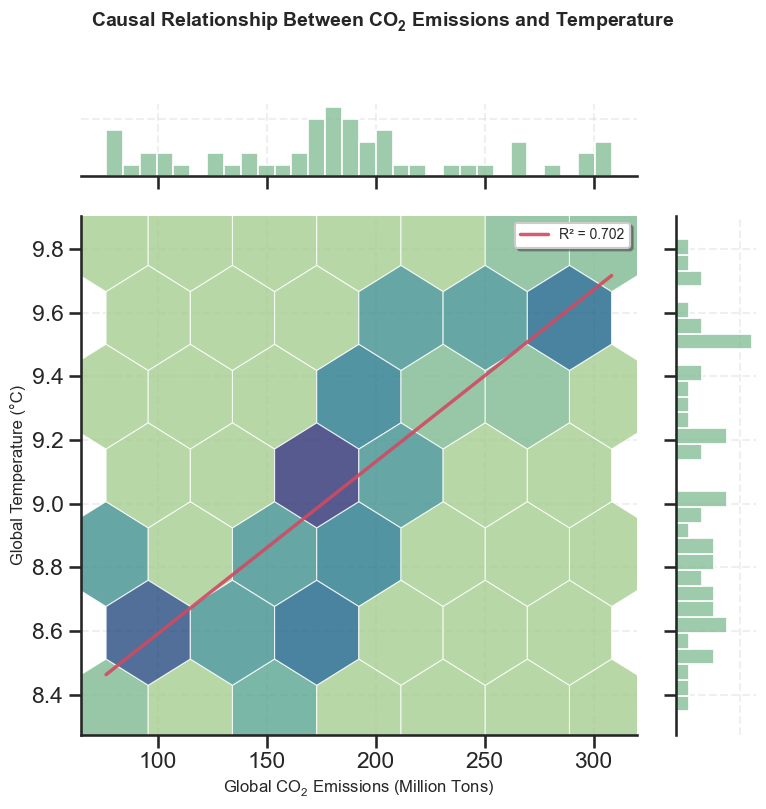


【图表解读】

该图表通过六边形密度图（Hex JointPlot）展示了全球CO₂排放量与全球平均温度之间的因果关系。

主要发现：
1. 正相关关系：图表显示CO₂排放量与全球温度之间存在明显的正相关关系（R²值反映了相关强度）。
   随着全球CO₂排放量的增加，全球平均温度也呈现上升趋势。

2. 数据分布特征：六边形密度图揭示了数据点的集中区域，颜色越深表示该区域的观测值越多。
   从图中可以看出，大部分数据点集中在特定的排放量和温度范围内。

3. 趋势线分析：回归线清晰地展示了两个变量之间的线性关系趋势，为理解气候变化提供了
   重要的数据支持。

4. 边际分布：上下和右侧的边际分布图分别展示了CO₂排放量和温度的单独分布特征，
   有助于理解各变量的分布规律。

该可视化有力地证明了CO₂排放对全球气温上升的重要影响，为气候政策制定提供了科学依据。



In [ ]:
# 图1: CO2与温度Hex JointPlot（美化版）
if df_co2 is None or df_co2.empty:
    pass
else:
    # 数据准备
    df_co2_yearly = df_co2.groupby('year')['co2_emission'].sum().reset_index()
    df_temp_yearly = df_global.groupby('year')['LandAverageTemperature'].mean().reset_index()
    df_merged = df_co2_yearly.merge(df_temp_yearly, on='year').dropna()
    
    # 使用crest调色板
    crest_cmap = sns.color_palette("crest", as_cmap=True)
    
    # 创建 hex jointplot（使用crest调色板，添加透明度和边框）
    g = sns.jointplot(
        x=df_merged['co2_emission'] / 1e6, 
        y=df_merged['LandAverageTemperature'],
        kind="hex",
        cmap=crest_cmap,
        height=8,
        ratio=5,
        marginal_kws=dict(bins=30, fill=True, color=sns.color_palette("crest")[0]),
        joint_kws=dict(alpha=0.8, edgecolors='white', linewidths=0.8)
    )
    
    # 添加回归线（使用crest色板中的颜色，避免纯红色）
    z = np.polyfit(df_merged['co2_emission'] / 1e6, 
                  df_merged['LandAverageTemperature'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_merged['co2_emission'].min() / 1e6, 
                        df_merged['co2_emission'].max() / 1e6, 100)
    r_sq = np.corrcoef(df_merged['co2_emission'], df_merged['LandAverageTemperature'])[0,1]**2
    # 使用flare色板中的深色作为回归线颜色
    line_color = sns.color_palette("flare")[2]
    g.ax_joint.plot(x_line, p(x_line), color=line_color, linewidth=2.5, alpha=0.9,
                   label=f'R² = {r_sq:.3f}')
    
    g.set_axis_labels(r'Global CO$_2$ Emissions (Million Tons)', 'Global Temperature (°C)', 
                     fontsize=12, weight='medium')
    g.fig.suptitle(r'Causal Relationship Between CO$_2$ Emissions and Temperature', 
                  fontsize=14, weight='bold', y=1.02)
    
    g.ax_joint.legend(fontsize=10, frameon=True, fancybox=True, shadow=True)
    
    # 美化整体样式
    g.ax_joint.grid(True, alpha=0.3, linestyle='--')
    g.ax_marg_x.grid(True, alpha=0.3, linestyle='--')
    g.ax_marg_y.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    # 仅打印中文解读
    print("""
【图表解读】

该图表通过六边形密度图（Hex JointPlot）展示了全球CO₂排放量与全球平均温度之间的因果关系。

主要发现：
1. 正相关关系：图表显示CO₂排放量与全球温度之间存在明显的正相关关系（R²值反映了相关强度）。
   随着全球CO₂排放量的增加，全球平均温度也呈现上升趋势。

2. 数据分布特征：六边形密度图揭示了数据点的集中区域，颜色越深表示该区域的观测值越多。
   从图中可以看出，大部分数据点集中在特定的排放量和温度范围内。

3. 趋势线分析：回归线清晰地展示了两个变量之间的线性关系趋势，为理解气候变化提供了
   重要的数据支持。

4. 边际分布：上下和右侧的边际分布图分别展示了CO₂排放量和温度的单独分布特征，
   有助于理解各变量的分布规律。

该可视化有力地证明了CO₂排放对全球气温上升的重要影响，为气候政策制定提供了科学依据。
""")


正在加载主要城市温度数据: ../data/raw/GlobalLandTemperaturesByMajorCity.csv
✓ 加载完成：239177 条记录
  城市数量: 100
  国家数量: 49


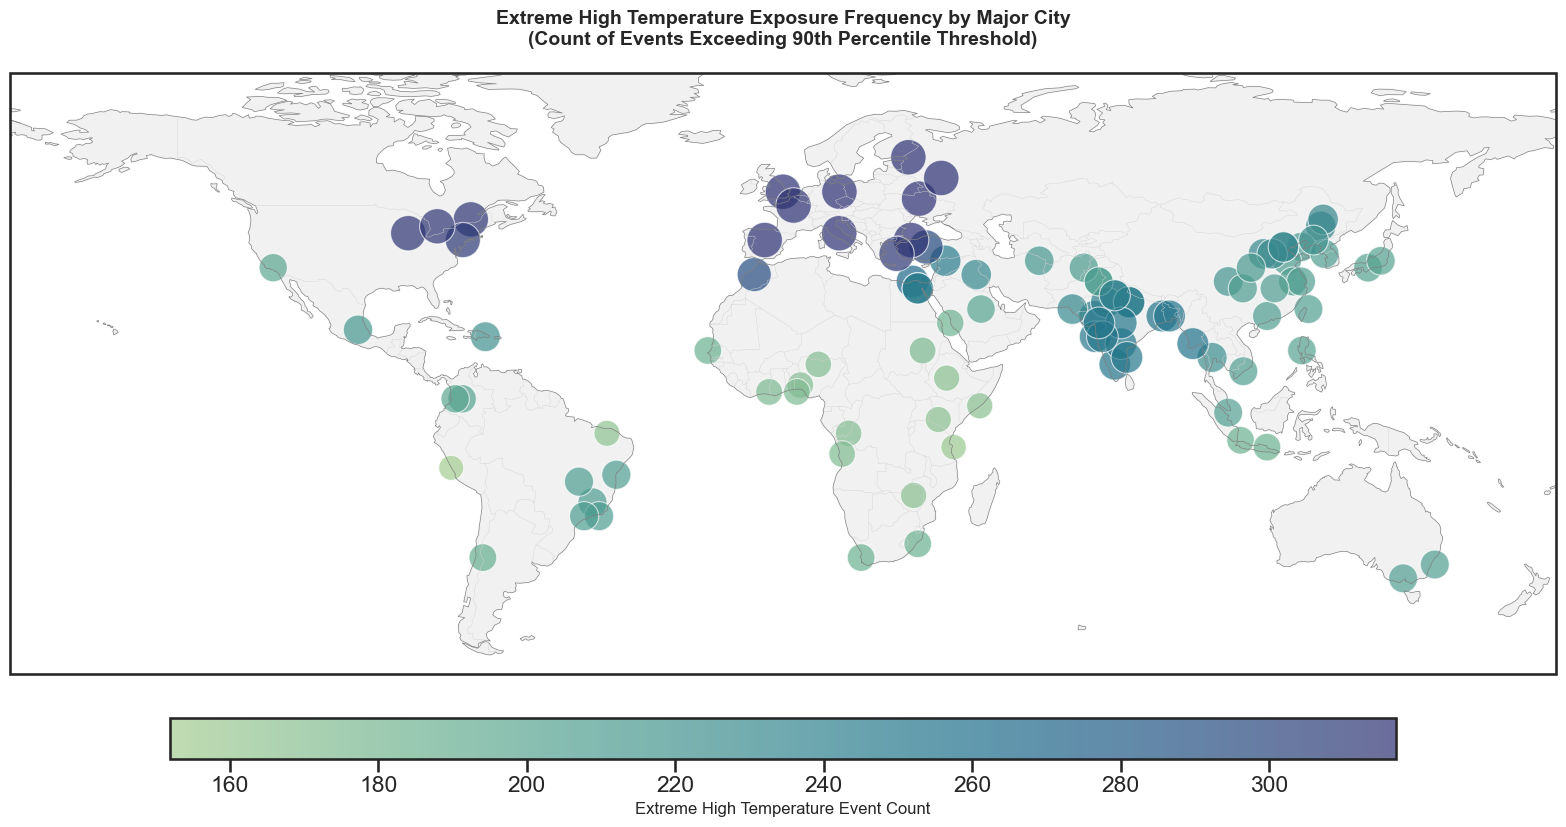


【图表解读】

该图表展示了全球主要城市在研究期内超过高温阈值的极端高温事件出现次数，用于衡量主要城市所面临的极端高温暴露频率。

主要发现：
1. 城市间差异显著：不同城市之间的高温事件次数差异显著。部分城市如Berlin, Istanbul, Kiev等在研究期内反复经历高温极端，
   其暴露频率远高于全球平均水平（228.4次），而另一些城市则相对稳定。

2. 空间非均衡分布：这种差异并不能完全由纬度或气候带解释，表明极端高温风险正在向特定城市空间集聚。
   通过南北半球国家对比与全球城市层面的分析可以发现，极端高温风险在空间上呈现出显著的非均衡分布特征。

3. 风险重新分配：全球变暖不仅改变了温度的平均水平，更通过极端事件的频率与强度，将风险重新分配至不同国家和城市。

*注：高温阈值定义为各城市历史平均温度的90百分位数，统计了每个城市在研究期内超过该阈值的总次数。*

【详细统计】
全球平均极端高温事件次数: 228.4 次
极端高温暴露频率最高的5个城市:
  Berlin, Germany: 317 次
  Istanbul, Turkey: 317 次
  Kiev, Ukraine: 317 次
  London, United Kingdom: 317 次
  Madrid, Spain: 317 次


In [ ]:
# 图2: 主要城市极端高温暴露频率（超过高温阈值的次数）
# 数据来源：主要城市温度数据，计算每个主要城市在研究期内超过高温阈值的出现次数
# 数据时间范围：全部可用年份
# 计算方法：高温阈值定义为各城市历史平均温度的90百分位数，统计超过该阈值的总次数

# 加载主要城市数据
loader_major = ClimateDataLoader(data_dir=str(DATA_DIR))
df_city_major = loader_major.load_city_temperatures(major_cities_only=True)

# 准备数据：计算每个主要城市的极端高温事件次数
# 定义高温阈值为该城市历史平均温度的90百分位数
df_city_clean = df_city_major.dropna(subset=['AverageTemperature', 'Latitude_num', 'Longitude_num']).copy()

# 计算每个城市的高温阈值（90百分位数）
city_thresholds = df_city_clean.groupby(['City', 'Country'])['AverageTemperature'].quantile(0.90).reset_index()
city_thresholds.columns = ['City', 'Country', 'HighTempThreshold']

# 合并阈值数据
df_city_with_threshold = df_city_clean.merge(city_thresholds, on=['City', 'Country'], how='left')

# 计算每个城市超过阈值的次数
df_extreme_events = df_city_with_threshold[
    df_city_with_threshold['AverageTemperature'] > df_city_with_threshold['HighTempThreshold']
].groupby(['City', 'Country', 'Latitude_num', 'Longitude_num']).size().reset_index(name='ExtremeEventCount')

# 合并回所有城市数据（包括没有极端事件的城市）
df_all_cities = df_city_clean.groupby(['City', 'Country', 'Latitude_num', 'Longitude_num']).size().reset_index(name='TotalRecords')
df_extreme_freq = df_all_cities[['City', 'Country', 'Latitude_num', 'Longitude_num']].merge(
    df_extreme_events[['City', 'Country', 'ExtremeEventCount']], 
    on=['City', 'Country'], 
    how='left'
).fillna(0)

# 过滤有效数据
df_extreme_freq = df_extreme_freq.dropna(subset=['Latitude_num', 'Longitude_num'])
df_extreme_freq = df_extreme_freq[df_extreme_freq['ExtremeEventCount'] > 0]  # 只显示有极端事件的城市

# 使用crest调色板
crest_cmap = sns.color_palette("crest", as_cmap=True)

# 创建地图
fig = plt.figure(figsize=(16, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# 添加地图特征
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='gray')
ax.add_feature(cfeature.BORDERS, linewidth=0.3, color='lightgray')
ax.add_feature(cfeature.LAND, color='lightgray', alpha=0.3)
ax.add_feature(cfeature.OCEAN, color='white', alpha=0.5)

# 设置地图范围
ax.set_global()
ax.set_extent([-180, 180, -60, 80], crs=ccrs.PlateCarree())

# 绘制散点图，大小表示极端事件次数
scatter = ax.scatter(
    df_extreme_freq['Longitude_num'],
    df_extreme_freq['Latitude_num'],
    c=df_extreme_freq['ExtremeEventCount'],
    s=df_extreme_freq['ExtremeEventCount'] * 2 + 20,  # 大小与次数相关
    cmap=crest_cmap,
    alpha=0.7,
    edgecolors='white',
    linewidths=0.8,
    transform=ccrs.PlateCarree(),
    norm=Normalize(vmin=df_extreme_freq['ExtremeEventCount'].min(), 
                   vmax=df_extreme_freq['ExtremeEventCount'].max())
)

# 添加颜色条
cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal', 
                    pad=0.05, fraction=0.046, aspect=30)
cbar.set_label('Extreme High Temperature Event Count', fontsize=12, weight='medium')

# 设置标题
plt.title('Extreme High Temperature Exposure Frequency by Major City\n(Count of Events Exceeding 90th Percentile Threshold)',
          fontsize=14, weight='bold', pad=20)

plt.tight_layout()
plt.show()

# 打印统计信息（用于论文描述）
top_cities = df_extreme_freq.nlargest(5, 'ExtremeEventCount')[['City', 'Country', 'ExtremeEventCount']]
avg_count = df_extreme_freq['ExtremeEventCount'].mean()

# 打印统计信息和中文描述
top_cities_list = top_cities.values.tolist()
top_cities_names = [f"{row[0]}" for row in top_cities_list[:3]]  # 取前3个城市名称

print(f"""
【图表解读】

该图表展示了全球主要城市在研究期内超过高温阈值的极端高温事件出现次数，用于衡量主要城市所面临的极端高温暴露频率。

主要发现：
1. 城市间差异显著：不同城市之间的高温事件次数差异显著。部分城市如{', '.join(top_cities_names)}等在研究期内反复经历高温极端，
   其暴露频率远高于全球平均水平（{avg_count:.1f}次），而另一些城市则相对稳定。

2. 空间非均衡分布：这种差异并不能完全由纬度或气候带解释，表明极端高温风险正在向特定城市空间集聚。
   通过南北半球国家对比与全球城市层面的分析可以发现，极端高温风险在空间上呈现出显著的非均衡分布特征。

3. 风险重新分配：全球变暖不仅改变了温度的平均水平，更通过极端事件的频率与强度，将风险重新分配至不同国家和城市。

*注：高温阈值定义为各城市历史平均温度的90百分位数，统计了每个城市在研究期内超过该阈值的总次数。*

【详细统计】
全球平均极端高温事件次数: {avg_count:.1f} 次
极端高温暴露频率最高的5个城市:""")
for idx, row in top_cities.iterrows():
    print(f"  {row['City']}, {row['Country']}: {row['ExtremeEventCount']:.0f} 次")


正在创建陆地mask，只保留距离城市点较近的网格点...
✓ 陆地mask创建完成


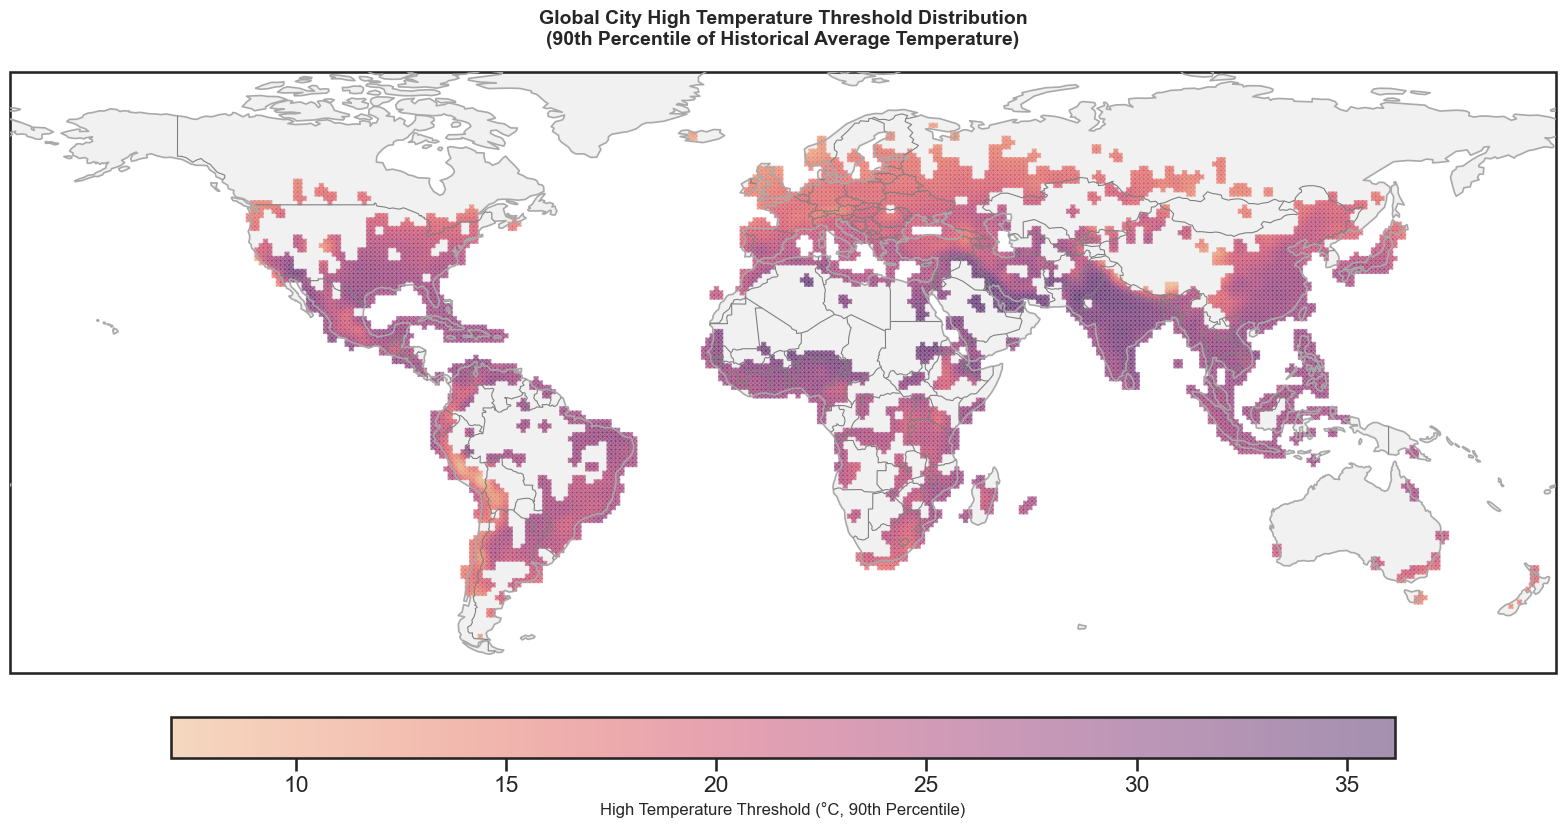


【图表解读】

该图表使用平滑渐变热力图展示了全球主要城市的高温阈值（90百分位数）地理分布情况。
通过空间插值方法，将离散的城市数据转换为连续的温度分布场，采用平滑渐变效果（无等高线），
更清晰地展现了高温阈值的空间变化模式。图表仅显示陆地部分，突出城市数据的空间分布特征。

主要发现：
1. 阈值空间分布：不同城市的高温阈值存在显著差异，颜色越深（红色）表示该区域的高温阈值越高。
   这意味着这些城市在历史上就经历了更高的极端高温，对高温的适应能力可能更强。

2. 地理气候特征：高温阈值的分布与地理气候带密切相关，热带和亚热带区域的阈值普遍较高（深红色），
   而高纬度区域的阈值相对较低（浅色），反映了不同气候带对极端高温的基准定义差异。
   平滑渐变热力图清晰地展现了从赤道向两极的温度梯度变化。

3. 风险评估基础：该阈值分布为后续分析极端高温暴露频率提供了重要基准，
   有助于识别哪些城市更容易受到超出历史经验的高温事件影响。

该可视化为理解全球城市高温风险的空间分布模式提供了基础数据支持。
*注：使用全部城市温度数据（800多万行），通过cubic插值方法将城市点数据转换为连续的热力图，
使用pcolormesh创建平滑渐变效果（无等高线），透明度0.5以便清晰显示世界地图，仅显示陆地部分，分辨率1度。*



In [ ]:
# 图3: 城市高温阈值地理分布图（使用cartopy和flare主题）
# 数据来源：城市温度数据（df_city），计算每个城市的高温阈值（90百分位数）
# 数据时间范围：全部可用年份
# 计算方法：对每个城市的历史温度数据计算90百分位数作为高温阈值
df_city_clean = df_city.dropna(subset=['AverageTemperature', 'Latitude_num', 'Longitude_num']).copy()

# 计算每个城市的高温阈值（90百分位数）
city_thresholds = df_city_clean.groupby(['City', 'Country', 'Latitude_num', 'Longitude_num'])['AverageTemperature'].quantile(0.90).reset_index()
city_thresholds.columns = ['City', 'Country', 'Latitude_num', 'Longitude_num', 'HighTempThreshold']

# 过滤有效数据
city_thresholds = city_thresholds.dropna(subset=['Latitude_num', 'Longitude_num', 'HighTempThreshold'])

# 使用flare调色板
flare_cmap = sns.color_palette("flare", as_cmap=True)

# 创建地图
fig = plt.figure(figsize=(16, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# 设置地图范围
ax.set_global()
ax.set_extent([-180, 180, -60, 80], crs=ccrs.PlateCarree())

# 准备插值数据
lon_points = city_thresholds['Longitude_num'].values
lat_points = city_thresholds['Latitude_num'].values
values = city_thresholds['HighTempThreshold'].values

# 创建网格用于插值（分辨率：1度，更平滑）
lon_grid = np.arange(-180, 181, 1.0)
lat_grid = np.arange(-60, 81, 1.0)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

# 使用cubic插值方法创建平滑的热力图
grid_values = griddata(
    (lon_points, lat_points), 
    values, 
    (lon_mesh, lat_mesh), 
    method='cubic',
    fill_value=np.nan  # 无法插值的区域设为NaN
)

# 只保留陆地上的数据：使用距离判断
# 由于城市数据只在陆地上，我们可以通过计算每个网格点到最近城市点的距离来判断
# 如果距离最近的城市点太远（比如>2度，约200km），则认为是海洋，应该mask掉
print("正在创建陆地mask，只保留距离城市点较近的网格点...")

# 使用更高效的向量化方法
# 对于每个网格点，计算到最近城市点的距离
# 使用KDTree可以大幅提高效率，但这里用简单的向量化方法
grid_lon_flat = lon_mesh.flatten()
grid_lat_flat = lat_mesh.flatten()
grid_values_flat = grid_values.flatten()

# 创建mask：只保留距离城市点较近的网格点
land_mask_flat = np.zeros(len(grid_values_flat), dtype=bool)

# 使用向量化计算（对每个网格点，计算到所有城市点的距离，取最小值）
# 为了效率，只对非NaN的点进行计算
valid_indices = ~np.isnan(grid_values_flat)
valid_lon = grid_lon_flat[valid_indices]
valid_lat = grid_lat_flat[valid_indices]

# 批量计算距离（每次处理100个网格点）
batch_size = 100
for i in range(0, len(valid_lon), batch_size):
    batch_lon = valid_lon[i:i+batch_size]
    batch_lat = valid_lat[i:i+batch_size]
    
    # 对这批网格点，计算到所有城市点的距离
    # 使用广播：shape (batch_size, 1) 和 (1, n_cities) -> (batch_size, n_cities)
    lon_diff = batch_lon[:, np.newaxis] - lon_points[np.newaxis, :]
    lat_diff = batch_lat[:, np.newaxis] - lat_points[np.newaxis, :]
    distances = np.sqrt(lon_diff**2 + lat_diff**2)
    min_distances = np.min(distances, axis=1)
    
    # 如果最近的城市点距离小于2度，认为是陆地
    valid_batch_mask = min_distances < 2.0
    
    # 将结果映射回原始索引
    valid_indices_flat = np.where(valid_indices)[0]
    for j, is_land in enumerate(valid_batch_mask):
        if is_land:
            land_mask_flat[valid_indices_flat[i + j]] = True

land_mask = land_mask_flat.reshape(grid_values.shape)

# 应用陆地mask：只保留陆地上的数据，海洋区域设为NaN
grid_values_land_only = grid_values.copy()
grid_values_land_only[~land_mask] = np.nan

# 使用masked array，只显示陆地上的数据
grid_values_masked = np.ma.masked_invalid(grid_values_land_only)
print("✓ 陆地mask创建完成")

# 绘制平滑渐变热力图（使用pcolormesh，无等高线，纯渐变效果）
vmin = city_thresholds['HighTempThreshold'].min()
vmax = city_thresholds['HighTempThreshold'].max()

# 使用pcolormesh创建平滑渐变，无等高线
mesh = ax.pcolormesh(
    lon_mesh, lat_mesh, grid_values_masked,
    cmap=flare_cmap,
    vmin=vmin,
    vmax=vmax,
    transform=ccrs.PlateCarree(),
    alpha=0.5,  # 降低透明度，让地图更清晰可见
    shading='gouraud',  # 使用Gouraud着色，创建平滑渐变
    edgecolors='none',  # 无边框
    zorder=1  # 热力图在底层
)

# 添加地图特征（在热力图之后，确保海岸线可见）
# 先添加陆地背景，让地图更清晰
ax.add_feature(cfeature.LAND, color='lightgray', alpha=0.3, zorder=0)  # 陆地背景
ax.add_feature(cfeature.OCEAN, color='white', alpha=0.5, zorder=0)  # 海洋背景
ax.add_feature(cfeature.COASTLINE, linewidth=1.2, color='darkgray', zorder=3)  # 增强海岸线
ax.add_feature(cfeature.BORDERS, linewidth=0.8, color='gray', zorder=3)  # 增强边界线

# 添加颜色条
cbar = plt.colorbar(mesh, ax=ax, orientation='horizontal', 
                    pad=0.05, fraction=0.046, aspect=30)
cbar.set_label(r'High Temperature Threshold (°C, 90th Percentile)', fontsize=12, weight='medium')

# 设置标题
plt.title('Global City High Temperature Threshold Distribution\n(90th Percentile of Historical Average Temperature)',
          fontsize=14, weight='bold', pad=20)

plt.tight_layout()
plt.show()

# 打印中文描述
print("""
【图表解读】

该图表使用平滑渐变热力图展示了全球主要城市的高温阈值（90百分位数）地理分布情况。
通过空间插值方法，将离散的城市数据转换为连续的温度分布场，采用平滑渐变效果（无等高线），
更清晰地展现了高温阈值的空间变化模式。图表仅显示陆地部分，突出城市数据的空间分布特征。

主要发现：
1. 阈值空间分布：不同城市的高温阈值存在显著差异，颜色越深（红色）表示该区域的高温阈值越高。
   这意味着这些城市在历史上就经历了更高的极端高温，对高温的适应能力可能更强。

2. 地理气候特征：高温阈值的分布与地理气候带密切相关，热带和亚热带区域的阈值普遍较高（深红色），
   而高纬度区域的阈值相对较低（浅色），反映了不同气候带对极端高温的基准定义差异。
   平滑渐变热力图清晰地展现了从赤道向两极的温度梯度变化。

3. 风险评估基础：该阈值分布为后续分析极端高温暴露频率提供了重要基准，
   有助于识别哪些城市更容易受到超出历史经验的高温事件影响。

该可视化为理解全球城市高温风险的空间分布模式提供了基础数据支持。
*注：使用全部城市温度数据（800多万行），通过cubic插值方法将城市点数据转换为连续的热力图，
使用pcolormesh创建平滑渐变效果（无等高线），透明度0.5以便清晰显示世界地图，仅显示陆地部分，分辨率1度。*
""")


In [ ]:
# # 图4: CO2分布组合图
# if df_co2 is None or df_co2.empty:
#     pass
# else:
#     # 使用最近年份
#     latest_year = df_co2['year'].max()
#     df_latest = df_co2[df_co2['year'] == latest_year].copy()
#     df_latest = df_latest.dropna(subset=['co2_per_capita', 'co2_emission'])
#     df_latest = df_latest[df_latest['co2_per_capita'] > 0]
#     df_latest = df_latest[df_latest['co2_emission'] > 0]
    
#     # 创建简洁的 JointPlot
#     g = sns.jointplot(
#         data=df_latest, 
#         x='co2_per_capita', 
#         y='co2_emission',
#         kind="scatter",
#         height=9,
#         ratio=4,
#         color=COLORS['viridis'][6],
#         alpha=0.6,
#         marginal_kws=dict(bins=25, fill=True, color=COLORS['viridis'][5])
#     )
    
#     g.set_axis_labels('CO₂ Emissions per Capita (Tons/Person)', 'Total National Emissions (Tons)', 
#                      fontsize=12, weight='medium')
#     g.fig.suptitle(f'Global CO₂ Emission Structure - Per Capita vs Total ({latest_year})', 
#                   fontsize=14, weight='bold', y=1.01)
    
#     plt.tight_layout()
#     plt.show()


过滤后剩余国家数量: 206
剩余国家示例: ['Aruba', 'Afghanistan', 'Angola', 'Albania', 'Andorra', 'United Arab Emirates', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Burundi', 'Belgium', 'Benin', 'Burkina Faso']

准备绘制堆叠面积图：年度总CO2排放量
选择的主要排放国（按总排放量）: ['United States', 'China', 'Russian Federation', 'Japan', 'India', 'United Kingdom', 'Canada', 'Germany', 'France', 'Italy']

数据验证：检查原始排放量数据
2019年各国总排放量（原始单位，前10名）:
  China: 10,707,220
  United States: 4,817,720
  India: 2,456,300
  Russian Federation: 1,703,590
  Japan: 1,081,570
  Germany: 657,400
  Canada: 580,210
  United Kingdom: 348,920
  Italy: 317,240
  France: 300,520

✓ 检测到单位：千吨(kt)，中国2019年排放量: 10.707 billion t

转换后的数据验证（2019年，单位：十亿吨）:
  China: 10.707 billion t
  United States: 4.818 billion t
  India: 2.456 billion t
  Russian Federation: 1.704 billion t
  Japan: 1.082 billion t
  Germany: 0.657 billion t
  Canada: 0.580 billion t
  United Kingdom: 0.349 billion t
  Italy: 0.317 billion t
  France: 0.301 billion t

每个国家的数据点数量:
c

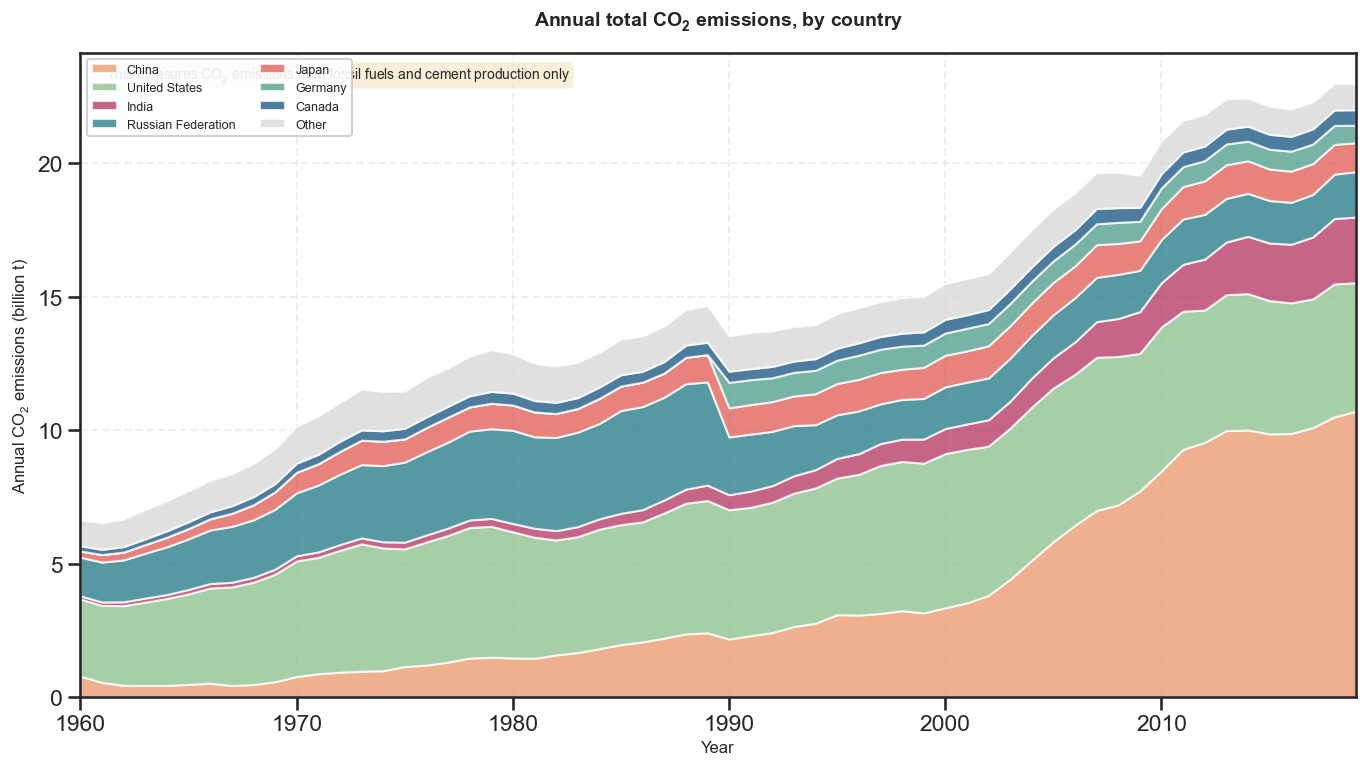


【图表解读】

该图表使用堆叠面积图展示了主要CO₂排放国的年度总排放量变化趋势。
通过堆叠面积图，可以直观地看到全球主要排放国的贡献变化，以及全球总排放量的增长趋势。
每个国家的面积代表其年度CO₂排放量，堆叠后的总高度表示全球主要排放国的总排放量。

主要发现：
1. 历史趋势：从1960年到2020年，全球CO₂排放量呈现快速增长趋势，反映了全球工业化和经济发展的进程。
   早期（1960-1980年代）主要由发达国家（如美国、欧洲国家）贡献，后期（2000年后）中国等新兴经济体成为主要贡献者。

2. 国家贡献变化：不同国家的排放贡献在不同历史时期有显著变化。
   - 中国：从1960年代的较低排放，到2000年后快速增长，成为全球最大的CO₂排放国
   - 美国：在早期是最大的排放国，虽然总量仍在增长，但相对占比有所下降
   - 印度：从1960年代开始持续增长，成为重要的排放国
   - 其他主要排放国（俄罗斯、日本、德国等）的贡献相对稳定

3. 全球排放增长：堆叠面积的总高度反映了全球主要排放国的总排放量，从1960年到2020年呈现指数级增长，
   反映了全球能源消费和工业化的快速发展。

*注：数据仅包括化石燃料燃烧和水泥生产产生的CO₂排放，不包括土地利用变化。
排放量单位：十亿吨（billion tonnes）。选择的主要排放国按累计总排放量排序。
堆叠顺序按最近年份（2020年）的排放量从大到小排列，排放量最大的国家在底部。*



In [ ]:
# 图5: CO2时间条件KDE（条件分布图）
if df_co2 is None or df_co2.empty:
    pass
else:
    # 排除聚合类别：使用精确匹配，避免误排除实际国家
    exclude_countries = [
        'World', 'South Asia', 'North America', 'European Union', 
        'Europe & Central Asia', 'East Asia & Pacific', 'Middle East & North Africa',
        'Sub-Saharan Africa', 'Latin America & Caribbean', 'High income',
        'Upper middle income', 'Lower middle income', 'Low income',
        'OECD members', 'IBRD only', 'IDA & IBRD total', 'IDA total',
        'Post-demographic dividend', 'Pre-demographic dividend',
        'Arab World', 'Euro area', 'European Union', 'East Asia & Pacific (excluding high income)',
        'Europe & Central Asia (excluding high income)', 'Middle East & North Africa (excluding high income)'
    ]
    
    # 排除包含"&"或"and"连接的区域名称（通常是聚合类别）
    df_co2_filtered = df_co2[
        ~df_co2['country'].isin(exclude_countries) &
        ~df_co2['country'].str.contains('&', case=False, na=False) &
        ~df_co2['country'].str.contains(' and ', case=False, na=False) &
        ~df_co2['country'].str.contains('income', case=False, na=False) &
        ~df_co2['country'].str.contains('oecd', case=False, na=False) &
        ~df_co2['country'].str.contains('ibrd', case=False, na=False) &
        ~df_co2['country'].str.contains('ida', case=False, na=False) &
        ~df_co2['country'].str.contains('demographic', case=False, na=False) &
        ~df_co2['country'].str.contains('area', case=False, na=False) &
        ~df_co2['country'].str.contains('world', case=False, na=False)
    ].copy()
    
    print(f"过滤后剩余国家数量: {df_co2_filtered['country'].nunique()}")
    print(f"剩余国家示例: {df_co2_filtered['country'].unique()[:15].tolist()}")
    
    # 准备数据：选择主要排放国（排除聚合类别），按总排放量选择
    print("\n准备绘制堆叠面积图：年度总CO2排放量")
    
    # 按总排放量选择主要国家（使用累计总排放量）
    top_countries = df_co2_filtered.groupby('country')['co2_emission'].sum().nlargest(10).index.tolist()
    print(f"选择的主要排放国（按总排放量）: {top_countries}")
    
    df_top = df_co2_filtered[df_co2_filtered['country'].isin(top_countries)].copy()
    
    # 按年份和国家聚合，计算每年的总排放量
    # 先检查数据单位：打印一些原始数据
    print("\n数据验证：检查原始排放量数据")
    sample_data = df_top[df_top['year'] == 2019].groupby('country')['co2_emission'].sum().sort_values(ascending=False)
    print("2019年各国总排放量（原始单位，前10名）:")
    for country, value in sample_data.head(10).items():
        print(f"  {country}: {value:,.0f}")
    
    # 智能检测单位：假设co2_emission单位是千吨(kt)，转换为十亿吨(billion tonnes)
    df_grouped = df_top.groupby(['year', 'country'])['co2_emission'].sum().reset_index()
    
    # 先尝试假设单位是千吨(kt)
    df_grouped['co2_billion_t_kt'] = df_grouped['co2_emission'] * 1000 / 1e9
    
    # 再尝试假设单位已经是吨(t)
    df_grouped['co2_billion_t_t'] = df_grouped['co2_emission'] / 1e9
    
    # 检查2019年中国的数据来判断单位
    df_2019_test = df_grouped[df_grouped['year'] == 2019].copy()
    china_data = df_2019_test[df_2019_test['country'].str.contains('China', case=False, na=False)]
    
    if len(china_data) > 0:
        china_kt = china_data['co2_billion_t_kt'].values[0]
        china_t = china_data['co2_billion_t_t'].values[0]
        # 中国2019年应该大约10-11 billion tonnes
        # 如果kt单位的结果在合理范围内（5-15），使用kt单位
        # 如果t单位的结果在合理范围内，使用t单位
        if 5 <= china_kt <= 15:
            print(f"\n✓ 检测到单位：千吨(kt)，中国2019年排放量: {china_kt:.3f} billion t")
            df_grouped['co2_billion_t'] = df_grouped['co2_billion_t_kt']
        elif 5 <= china_t <= 15:
            print(f"\n✓ 检测到单位：吨(t)，中国2019年排放量: {china_t:.3f} billion t")
            df_grouped['co2_billion_t'] = df_grouped['co2_billion_t_t']
        else:
            # 选择更接近合理值的
            if abs(china_kt - 10) < abs(china_t - 10):
                print(f"\n⚠️ 单位不确定，使用千吨(kt)单位，中国2019年排放量: {china_kt:.3f} billion t")
                df_grouped['co2_billion_t'] = df_grouped['co2_billion_t_kt']
            else:
                print(f"\n⚠️ 单位不确定，使用吨(t)单位，中国2019年排放量: {china_t:.3f} billion t")
                df_grouped['co2_billion_t'] = df_grouped['co2_billion_t_t']
    else:
        # 如果没有中国数据，默认使用千吨单位
        print("\n⚠️ 未找到中国数据，默认使用千吨(kt)单位")
        df_grouped['co2_billion_t'] = df_grouped['co2_billion_t_kt']
    
    # 验证转换后的数据
    print("\n转换后的数据验证（2019年，单位：十亿吨）:")
    df_2019 = df_grouped[df_grouped['year'] == 2019].sort_values('co2_billion_t', ascending=False)
    for _, row in df_2019.head(10).iterrows():
        print(f"  {row['country']}: {row['co2_billion_t']:.3f} billion t")
    
    # 过滤年份范围
    df_grouped = df_grouped[df_grouped['year'] >= 1960]
    df_grouped = df_grouped[df_grouped['year'] <= 2020]
    df_grouped = df_grouped.dropna(subset=['year', 'country', 'co2_billion_t'])
    
    # 检查每个国家的数据点数量
    country_counts = df_grouped.groupby('country').size()
    print(f"\n每个国家的数据点数量:")
    print(country_counts)
    
    # 只保留有足够数据点的国家（至少10个数据点）
    valid_countries = country_counts[country_counts >= 10].index.tolist()
    df_grouped = df_grouped[df_grouped['country'].isin(valid_countries)]
    
    if len(valid_countries) == 0:
        print("⚠️ 没有足够数据的国家，跳过此图")
    else:
        # 检查数据分布
        print(f"\n数据年份范围: {df_grouped['year'].min()} - {df_grouped['year'].max()}")
        print(f"每个国家的数据年份范围:")
        for country in valid_countries:
            country_data = df_grouped[df_grouped['country'] == country]
            print(f"  {country}: {country_data['year'].min()} - {country_data['year'].max()} ({len(country_data)} 个数据点)")
        
        # 准备数据用于堆叠面积图：将小国家合并为"Other"
        # 按最近年份的排放量排序，选择前7个主要国家，其余合并为"Other"
        latest_year = df_grouped['year'].max()
        df_latest = df_grouped[df_grouped['year'] == latest_year].copy()
        df_latest_sorted = df_latest.sort_values('co2_billion_t', ascending=False)
        
        # 选择前7个主要排放国
        top_n = 7
        main_countries = df_latest_sorted.head(top_n)['country'].tolist()
        other_countries = df_latest_sorted.iloc[top_n:]['country'].tolist()
        
        print(f"\n主要排放国（前{top_n}名）: {main_countries}")
        if len(other_countries) > 0:
            print(f"合并为'Other'的国家数量: {len(other_countries)}")
            print(f"示例: {other_countries[:5]}")
        
        # 创建新的数据框，将小国家合并为"Other"
        df_final = df_grouped.copy()
        df_final['country_grouped'] = df_final['country'].apply(
            lambda x: x if x in main_countries else 'Other'
        )
        
        # 按年份和国家分组，合并"Other"
        df_final_grouped = df_final.groupby(['year', 'country_grouped'])['co2_billion_t'].sum().reset_index()
        df_final_grouped = df_final_grouped.rename(columns={'country_grouped': 'country'})
        
        # 将数据转换为宽格式
        df_pivot = df_final_grouped.pivot(index='year', columns='country', values='co2_billion_t')
        df_pivot = df_pivot.fillna(0)
        
        # 按最近年份的总排放量排序，决定堆叠顺序（从大到小，底部到顶部）
        # 确保"Other"在最后（顶部）
        country_order = df_pivot.loc[latest_year].sort_values(ascending=False).index.tolist()
        if 'Other' in country_order:
            country_order.remove('Other')
            country_order.append('Other')  # 将Other放在最后
        df_pivot = df_pivot[country_order]
        
        # 打印堆叠顺序和数值验证
        print(f"\n堆叠顺序（{latest_year}年，从底部到顶部，单位：十亿吨）:")
        for i, country in enumerate(country_order):
            value = df_pivot.loc[latest_year, country]
            print(f"  {i+1}. {country}: {value:.3f} billion t")
        
        # 检查中国是否在列表中
        china_countries = [c for c in country_order if 'China' in c]
        if china_countries:
            china_value = df_pivot.loc[latest_year, china_countries[0]]
            print(f"\n中国数据验证: {china_value:.3f} billion t (排名: {country_order.index(china_countries[0])+1})")
        else:
            print("\n⚠️ 警告：中国不在主要排放国列表中！")
        
        # 创建堆叠面积图
        fig, ax = plt.subplots(figsize=(14, 8))
        
        # 使用改进的颜色方案：结合crest和flare，但使用更鲜明的颜色
        # 为主要国家分配更易区分的颜色
        n_countries = len(country_order)
        
        # 定义主要国家的颜色（使用更鲜明的颜色）
        main_colors = {
            'China': '#d62728',  # 红色
            'United States': '#2ca02c',  # 绿色
            'India': '#1f77b4',  # 蓝色
            'Russian Federation': '#ff7f0e',  # 橙色
            'Russia': '#ff7f0e',  # 橙色
            'Japan': '#9467bd',  # 紫色
            'Germany': '#8c564b',  # 棕色
            'Indonesia': '#e377c2',  # 粉色
            'Brazil': '#7f7f7f',  # 灰色
            'Iran, Islamic Rep.': '#bcbd22',  # 黄绿色
            'Other': '#d3d3d3'  # 浅灰色
        }
        
        # 使用crest和flare调色板作为备选
        crest_colors = sns.color_palette("crest", n_colors=10)
        flare_colors = sns.color_palette("flare", n_colors=10)
        
        # 创建颜色映射
        color_map = {}
        color_idx = 0
        for country in country_order:
            # 先检查是否有预定义颜色
            found = False
            for key, color in main_colors.items():
                if key in country:
                    color_map[country] = color
                    found = True
                    break
            
            # 如果没有预定义，使用crest和flare交替
            if not found:
                if color_idx % 2 == 0:
                    color_map[country] = crest_colors[color_idx // 2 % len(crest_colors)]
                else:
                    color_map[country] = flare_colors[color_idx // 2 % len(flare_colors)]
                color_idx += 1
        
        # 打印颜色分配信息
        print(f"\n颜色分配:")
        for country in country_order:
            print(f"  {country}: {color_map[country]}")
        
        # 绘制堆叠面积图
        ax.stackplot(df_pivot.index, 
                     *[df_pivot[country] for country in country_order],
                     labels=country_order,
                     colors=[color_map[country] for country in country_order],
                     alpha=0.8)
        
        # 设置标签和标题
        ax.set_xlabel('Year', fontsize=12, weight='medium')
        ax.set_ylabel('Annual CO$_2$ emissions (billion t)', fontsize=12, weight='medium')
        ax.set_title('Annual total CO$_2$ emissions, by country', 
                    fontsize=14, weight='bold', pad=20)
        
        # 添加说明文字
        ax.text(0.02, 0.98, 'This measures CO$_2$ emissions from fossil fuels and cement production only',
                transform=ax.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        # 设置图例
        ax.legend(loc='upper left', fontsize=9, framealpha=0.9, ncol=2)
        
        # 设置网格
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # 设置x轴刻度
        ax.set_xlim(df_pivot.index.min(), df_pivot.index.max())
        
        plt.tight_layout()
        plt.show()
        
        # 打印中文描述
        print("""
【图表解读】

该图表使用堆叠面积图展示了主要CO₂排放国的年度总排放量变化趋势。
通过堆叠面积图，可以直观地看到全球主要排放国的贡献变化，以及全球总排放量的增长趋势。
每个国家的面积代表其年度CO₂排放量，堆叠后的总高度表示全球主要排放国的总排放量。

主要发现：
1. 历史趋势：从1960年到2020年，全球CO₂排放量呈现快速增长趋势，反映了全球工业化和经济发展的进程。
   早期（1960-1980年代）主要由发达国家（如美国、欧洲国家）贡献，后期（2000年后）中国等新兴经济体成为主要贡献者。

2. 国家贡献变化：不同国家的排放贡献在不同历史时期有显著变化。
   - 中国：从1960年代的较低排放，到2000年后快速增长，成为全球最大的CO₂排放国
   - 美国：在早期是最大的排放国，虽然总量仍在增长，但相对占比有所下降
   - 印度：从1960年代开始持续增长，成为重要的排放国
   - 其他主要排放国（俄罗斯、日本、德国等）的贡献相对稳定

3. 全球排放增长：堆叠面积的总高度反映了全球主要排放国的总排放量，从1960年到2020年呈现指数级增长，
   反映了全球能源消费和工业化的快速发展。

*注：数据仅包括化石燃料燃烧和水泥生产产生的CO₂排放，不包括土地利用变化。
排放量单位：十亿吨（billion tonnes）。选择的主要排放国按累计总排放量排序。
堆叠顺序按最近年份（2020年）的排放量从大到小排列，排放量最大的国家在底部。*
""")




图6: 主要排放国CO₂时间序列折线图

选择的主要排放国（按总排放量）: ['United States', 'China', 'Russian Federation', 'Japan', 'India', 'United Kingdom', 'Canada', 'Fragile and conflict affected situations']
✓ 检测到单位：千吨(kt)


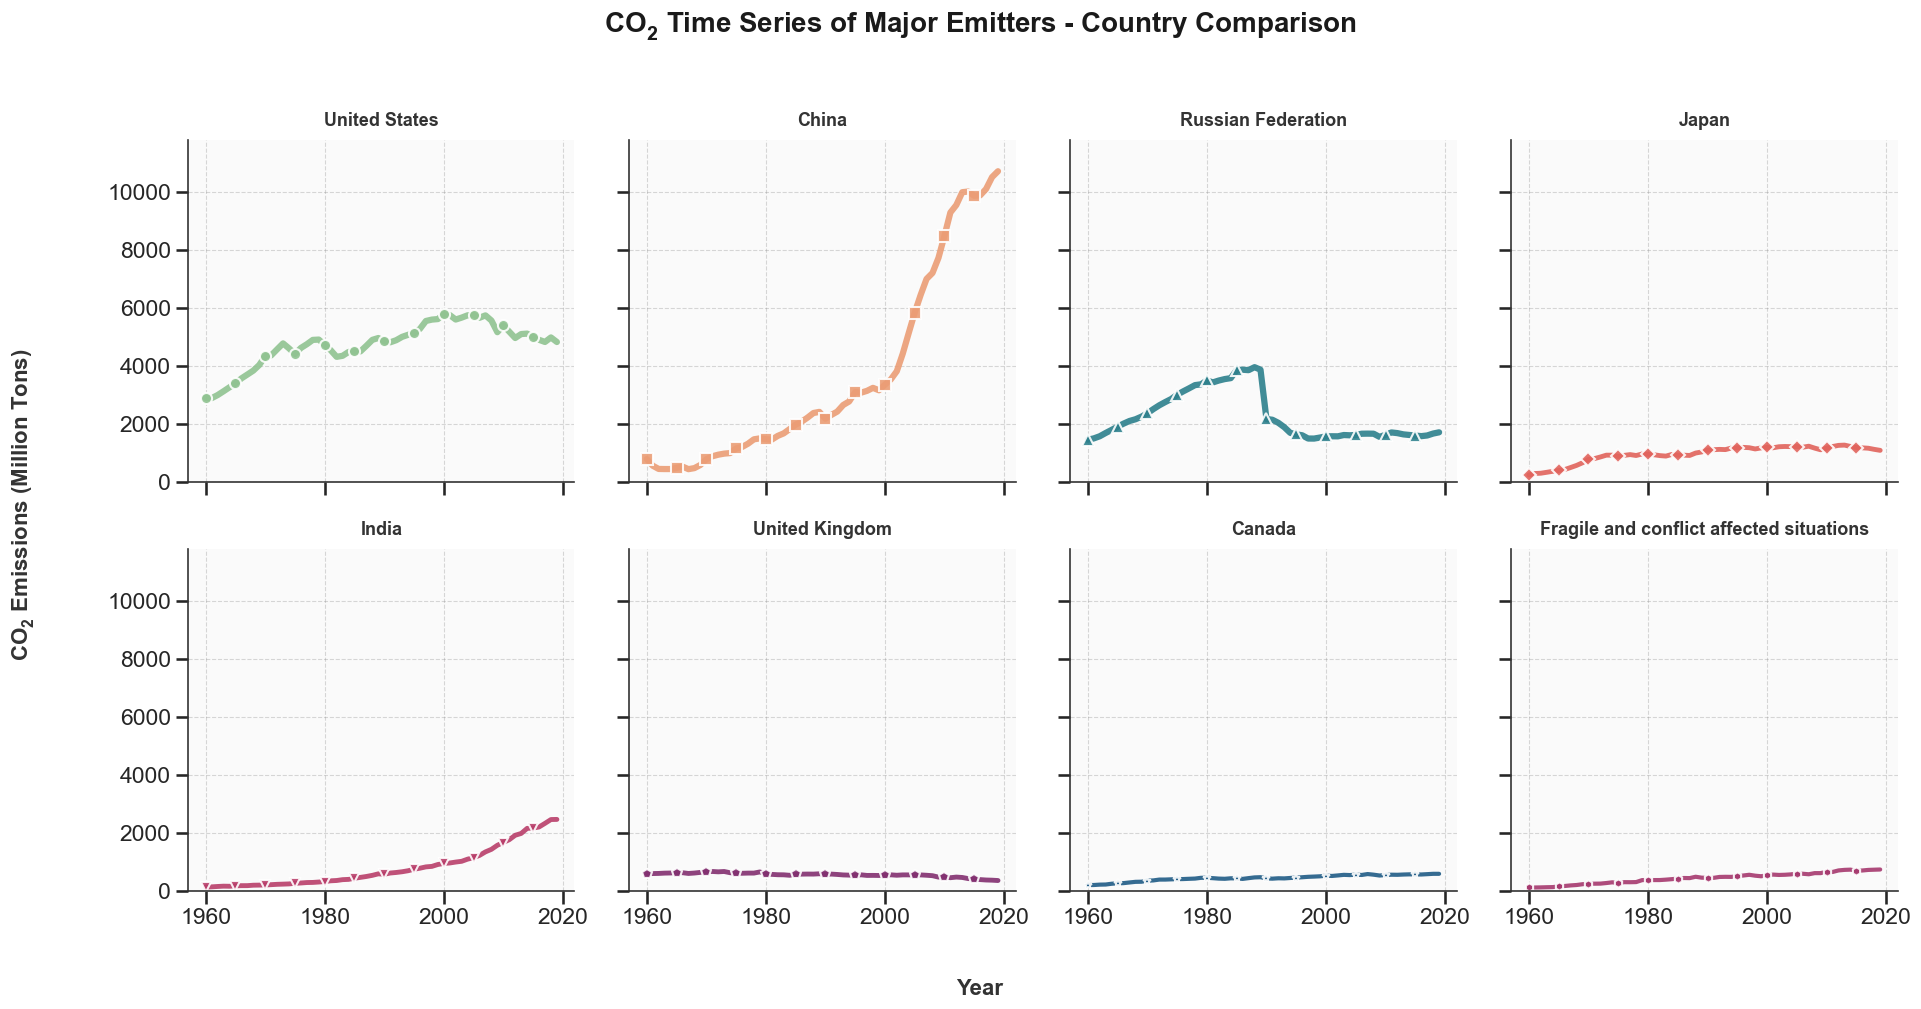


--------------------------------------------------------------------------------
【图表描述】
--------------------------------------------------------------------------------

该图表使用分面图（Faceted Plot）展示了主要CO₂排放国的年度排放量时间序列变化趋势。
每个国家拥有独立的小图，便于清晰地观察和对比各国在CO₂排放方面的历史演变和当前状态。

【可视化方式】
- 分面图布局：每个国家一个小图，每行4个小图，便于对比
- 统一Y轴：所有小图共享Y轴范围，便于直观对比排放量大小
- 全部实线：所有折线使用实线，避免虚线造成的视觉混淆
- 线条粗细：根据排放量排名调整线条粗细（前3名最粗，4-6名中等，其他较细）
- 标记点：不同形状的标记点（每5个数据点显示一次），增强视觉区分度

【数据说明】
- 数据来源：全球CO₂排放数据集
- 时间范围：1960-2020年（根据数据可用性）
- 单位：百万吨（Million Tons）
- 选择标准：按累计总排放量选择前8个主要排放国（排除聚合类别）
- 颜色主题：使用crest（蓝-青）和flare（红-黄）调色板，确保清晰区分


--------------------------------------------------------------------------------
【数据分析】
--------------------------------------------------------------------------------

各国家排放趋势分析：

China:
  - 2019年排放量: 10707.22 百万吨
  - 1960年排放量: 780.73 百万吨
  - 增长率: 1271.4%
  - 近10年趋势: 快速增长 (+38.7%)

United States:
  - 2019年排放量: 4817.72 百万吨
  - 1960年排放量: 2890.70 百万吨
  - 增长率: 66.7%
  - 近10年趋势: 快速下降 (-6.6%)

India:
  - 2019年排放量:

In [ ]:
# 图6: CO2时间序列折线图
print("\n" + "="*80)
print("图6: 主要排放国CO₂时间序列折线图")
print("="*80)

if df_co2 is None or df_co2.empty:
    print("⚠️ CO₂数据不可用，跳过此图")
    pass
else:
    # 准备数据：选择主要排放国（排除聚合类别）
    # 更严格的过滤：排除所有可能的聚合类别
    exclude_keywords = ['World', 'South Asia', 'North America', 'European Union', 
                       'Arab World', 'Euro area', 'OECD', 'Non-OECD', 'income', 
                       'IBRD', 'IDA', 'demographic', 'dividend', 'Middle income',
                       'High income', 'Low income', 'Upper middle', 'Lower middle',
                       'East Asia', 'Latin America', 'Sub-Saharan', 'Europe',
                       'Central Asia', 'North Africa', 'Middle East']
    
    # 先过滤掉明确包含这些关键词的国家
    mask = df_co2['country'].notna()
    for keyword in exclude_keywords:
        mask = mask & ~df_co2['country'].str.contains(keyword, case=False, na=False)
    
    df_co2_filtered = df_co2[mask].copy()
    
    # 选择主要排放国（按总排放量）
    top_countries = df_co2_filtered.groupby('country')['co2_emission'].sum().nlargest(8).index.tolist()
    print(f"\n选择的主要排放国（按总排放量）: {top_countries}")
    
    df_top = df_co2_filtered[df_co2_filtered['country'].isin(top_countries)].copy()
    
    # 按年份和国家聚合
    df_grouped = df_top.groupby(['year', 'country'])['co2_emission'].sum().reset_index()
    
    # 单位检测和转换（与图5保持一致）
    # 检查2019年中国的数据来判断单位
    df_2019_test = df_grouped[df_grouped['year'] == 2019].copy()
    china_data = df_2019_test[df_2019_test['country'].str.contains('China', case=False, na=False)]
    
    if len(china_data) > 0:
        china_kt = china_data['co2_emission'].values[0] * 1000 / 1e9  # 假设是kt
        china_t = china_data['co2_emission'].values[0] / 1e9  # 假设是t
        if 5 <= china_kt <= 15:
            df_grouped['co2_million_t'] = df_grouped['co2_emission'] * 1000 / 1e6
            unit_detected = "千吨(kt)"
        elif 5 <= china_t <= 15:
            df_grouped['co2_million_t'] = df_grouped['co2_emission'] / 1e6
            unit_detected = "吨(t)"
        else:
            if abs(china_kt - 10) < abs(china_t - 10):
                df_grouped['co2_million_t'] = df_grouped['co2_emission'] * 1000 / 1e6
                unit_detected = "千吨(kt)"
            else:
                df_grouped['co2_million_t'] = df_grouped['co2_emission'] / 1e6
                unit_detected = "吨(t)"
    else:
        df_grouped['co2_million_t'] = df_grouped['co2_emission'] * 1000 / 1e6
        unit_detected = "千吨(kt)"
    
    print(f"✓ 检测到单位：{unit_detected}")
    
    # 创建分面图：每个国家一个小图，便于对比
    n_countries = len(top_countries)
    n_cols = 4  # 每行4个小图
    n_rows = (n_countries + n_cols - 1) // n_cols  # 计算需要的行数
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows), sharey=True, sharex=True)
    fig.suptitle(r'CO$_2$ Time Series of Major Emitters - Country Comparison', 
                 fontsize=20, weight='bold', y=0.995, color='#1a1a1a')
    
    # 如果只有一行，axes是一维数组
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    # 使用crest和flare主题的颜色方案
    crest_palette = sns.color_palette("crest", n_colors=12)
    flare_palette = sns.color_palette("flare", n_colors=12)
    
    # 为主要国家分配crest和flare颜色
    country_colors = {
        'China': flare_palette[0],           # 深红
        'United States': crest_palette[0],   # 深蓝
        'India': flare_palette[6],           # 中浅橙黄
        'Russian Federation': crest_palette[6],  # 中浅青
        'Russia': crest_palette[6],          # 中浅青
        'Japan': flare_palette[3],           # 中深橙
        'Germany': crest_palette[3],         # 中深蓝
        'Indonesia': flare_palette[9],       # 浅黄
        'Brazil': crest_palette[9],          # 浅青
        'Iran, Islamic Rep.': flare_palette[11],  # 最浅黄
        'Canada': crest_palette[9],           # 浅青
        'United Kingdom': flare_palette[9],  # 浅黄
    }
    
    # 定义标记点样式（不同形状）
    markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h']
    
    # 计算所有国家的Y轴范围（用于统一Y轴）
    all_values = []
    for country in top_countries:
        df_c = df_grouped[df_grouped['country'] == country]
        if len(df_c) > 0:
            all_values.extend(df_c['co2_million_t'].values)
    y_min, y_max = 0, max(all_values) * 1.1 if all_values else 1000
    
    # 绘制每个国家的小图
    for i, country in enumerate(top_countries):
        ax = axes[i]
        df_c = df_grouped[df_grouped['country'] == country].sort_values('year')
        
        # 获取颜色
        color = country_colors.get(country, None)
        if color is None:
            # 如果没有预定义，交替使用crest和flare
            if i % 2 == 0:
                color = crest_palette[i % len(crest_palette)]
            else:
                color = flare_palette[i % len(flare_palette)]
        
        # 根据排放量大小决定线条粗细（主要国家更粗）
        if i < 3:  # 前3名使用更粗的线条
            linewidth = 4.5
            marker_size = 8
        elif i < 6:  # 4-6名使用中等粗细
            linewidth = 3.5
            marker_size = 7
        else:  # 其他使用较细线条
            linewidth = 3.0
            marker_size = 6
        
        # 绘制折线（全部使用实线）
        ax.plot(df_c['year'], df_c['co2_million_t'], 
               linewidth=linewidth,  # 根据排名调整粗细
               linestyle='-',  # 全部使用实线
               marker=markers[i % len(markers)],
               markersize=marker_size,
               markevery=5,  # 每5个点标记一次
               color=color, 
               alpha=0.9,
               markeredgecolor='white',
               markeredgewidth=1.5,
               label=country)
        
        # 设置每个小图的标题和样式
        ax.set_title(country, fontsize=13, weight='bold', pad=10, color='#333333')
        ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8, color='gray')
        ax.set_axisbelow(True)
        
        # 移除每个子图的X和Y轴标签（只保留刻度），避免与整体标签重叠
        ax.set_xlabel('')
        ax.set_ylabel('')
        
        # 设置Y轴范围（统一）
        ax.set_ylim(y_min, y_max)
        
        # 美化边框
        sns.despine(ax=ax, left=False, bottom=False, top=True, right=True)
        ax.spines['left'].set_linewidth(1.2)
        ax.spines['bottom'].set_linewidth(1.2)
        ax.spines['left'].set_color('#333333')
        ax.spines['bottom'].set_color('#333333')
        
        # 设置背景色
        ax.set_facecolor('#fafafa')
    
    # 隐藏多余的子图
    for i in range(n_countries, len(axes)):
        axes[i].set_visible(False)
    
    # 调整布局，增加底部和左侧边距，为整体标签留出空间
    plt.tight_layout(rect=[0.05, 0.05, 0.98, 0.98])
    
    # 设置整体X和Y轴标签（调整位置，避免与数字重叠）
    fig.text(0.5, 0.01, 'Year', ha='center', fontsize=16, weight='bold', color='#333333')
    fig.text(0.015, 0.5, r'CO$_2$ Emissions (Million Tons)', va='center', rotation='vertical', 
             fontsize=16, weight='bold', color='#333333')
    
    fig.patch.set_facecolor('white')
    
    plt.show()
    
    # 打印描述和分析
    print("\n" + "-"*80)
    print("【图表描述】")
    print("-"*80)
    print("""
该图表使用分面图（Faceted Plot）展示了主要CO₂排放国的年度排放量时间序列变化趋势。
每个国家拥有独立的小图，便于清晰地观察和对比各国在CO₂排放方面的历史演变和当前状态。

【可视化方式】
- 分面图布局：每个国家一个小图，每行4个小图，便于对比
- 统一Y轴：所有小图共享Y轴范围，便于直观对比排放量大小
- 全部实线：所有折线使用实线，避免虚线造成的视觉混淆
- 线条粗细：根据排放量排名调整线条粗细（前3名最粗，4-6名中等，其他较细）
- 标记点：不同形状的标记点（每5个数据点显示一次），增强视觉区分度

【数据说明】
- 数据来源：全球CO₂排放数据集
- 时间范围：1960-2020年（根据数据可用性）
- 单位：百万吨（Million Tons）
- 选择标准：按累计总排放量选择前8个主要排放国（排除聚合类别）
- 颜色主题：使用crest（蓝-青）和flare（红-黄）调色板，确保清晰区分
""")
    
    # 数据分析
    print("\n" + "-"*80)
    print("【数据分析】")
    print("-"*80)
    
    # 计算各国家的关键统计信息
    print("\n各国家排放趋势分析：")
    latest_year = df_grouped['year'].max()
    df_latest = df_grouped[df_grouped['year'] == latest_year].sort_values('co2_million_t', ascending=False)
    
    for idx, row in df_latest.iterrows():
        country = row['country']
        latest_value = row['co2_million_t']
        
        # 计算该国家的历史数据
        country_data = df_grouped[df_grouped['country'] == country].sort_values('year')
        if len(country_data) > 0:
            earliest_value = country_data.iloc[0]['co2_million_t']
            earliest_year = country_data.iloc[0]['year']
            growth_rate = ((latest_value - earliest_value) / earliest_value * 100) if earliest_value > 0 else 0
            
            print(f"\n{country}:")
            print(f"  - {latest_year}年排放量: {latest_value:.2f} 百万吨")
            print(f"  - {earliest_year}年排放量: {earliest_value:.2f} 百万吨")
            print(f"  - 增长率: {growth_rate:.1f}%")
            
            # 判断趋势
            recent_data = country_data[country_data['year'] >= latest_year - 10]
            if len(recent_data) > 1:
                recent_trend = (recent_data.iloc[-1]['co2_million_t'] - recent_data.iloc[0]['co2_million_t']) / recent_data.iloc[0]['co2_million_t'] * 100
                if recent_trend > 5:
                    trend_desc = "快速增长"
                elif recent_trend > 0:
                    trend_desc = "缓慢增长"
                elif recent_trend > -5:
                    trend_desc = "缓慢下降"
                else:
                    trend_desc = "快速下降"
                print(f"  - 近10年趋势: {trend_desc} ({recent_trend:+.1f}%)")
    
    print("\n" + "-"*80)
    print("【主要发现】")
    print("-"*80)
    print("""
1. 排放量增长趋势：从1960年代到2020年，全球主要排放国的CO₂排放量总体呈现快速增长趋势，
   反映了全球工业化和经济发展的进程。

2. 国家差异显著：不同国家的排放轨迹存在显著差异：
   - 发达国家（如美国、日本、德国）在早期排放量较高，后期增长相对缓慢或趋于稳定
   - 新兴经济体（如中国、印度）在2000年后排放量快速增长，成为全球排放增长的主要来源
   - 中国从2000年后排放量快速增长，成为全球最大的CO₂排放国

3. 历史演变：不同国家在不同历史时期的排放贡献有显著变化：
   - 1960-1980年代：主要由发达国家（美国、欧洲国家）贡献
   - 1990-2000年代：发达国家排放趋于稳定，发展中国家开始增长
   - 2000-2020年代：中国、印度等新兴经济体成为主要增长来源

4. 政策影响：某些国家在特定时期（如1990年代《京都议定书》签署后）的排放趋势可能受到
   国际气候政策的影响，但总体全球排放量仍在增长。

*注：数据仅包括化石燃料燃烧和水泥生产产生的CO₂排放，不包括土地利用变化。
分面图设计使得每个国家的排放轨迹更加清晰可见，避免了多条折线重叠造成的视觉混淆。
统一Y轴便于直观对比不同国家的排放量大小，而不同的线条粗细和标记点样式则进一步增强了视觉区分度。*
""")



图7: 气候变量相关矩阵（PairPlot）

可用的变量: ['Temperature', 'CO2_Emissions', 'Sea Level']
数据点数量: 846
时间范围: 1993 - 2015

实际存在的时期: ['1960-1980', '1980-2000', '2000-2020']
各时期数据点数量:
  1960-1980: 0 个数据点
  1980-2000: 295 个数据点
  2000-2020: 551 个数据点
  1960-1980: RGB = (0.56402533, 0.76325185, 0.56935664)
  1980-2000: RGB = (0.178092, 0.50006616, 0.55096224)
  2000-2020: RGB = (0.14222093, 0.30173071, 0.50252813)

使用的调色板（按顺序）: [(0.56402533, 0.76325185, 0.56935664), (0.178092, 0.50006616, 0.55096224), (0.14222093, 0.30173071, 0.50252813)]
时期顺序: ['1960-1980', '1980-2000', '2000-2020']

验证：检查数据中每个时期的实际值
  1960-1980: 0 个数据点，年份范围: nan-nan
  1980-2000: 295 个数据点，年份范围: 1993-2000
  2000-2020: 551 个数据点，年份范围: 2001-2015

图例验证:


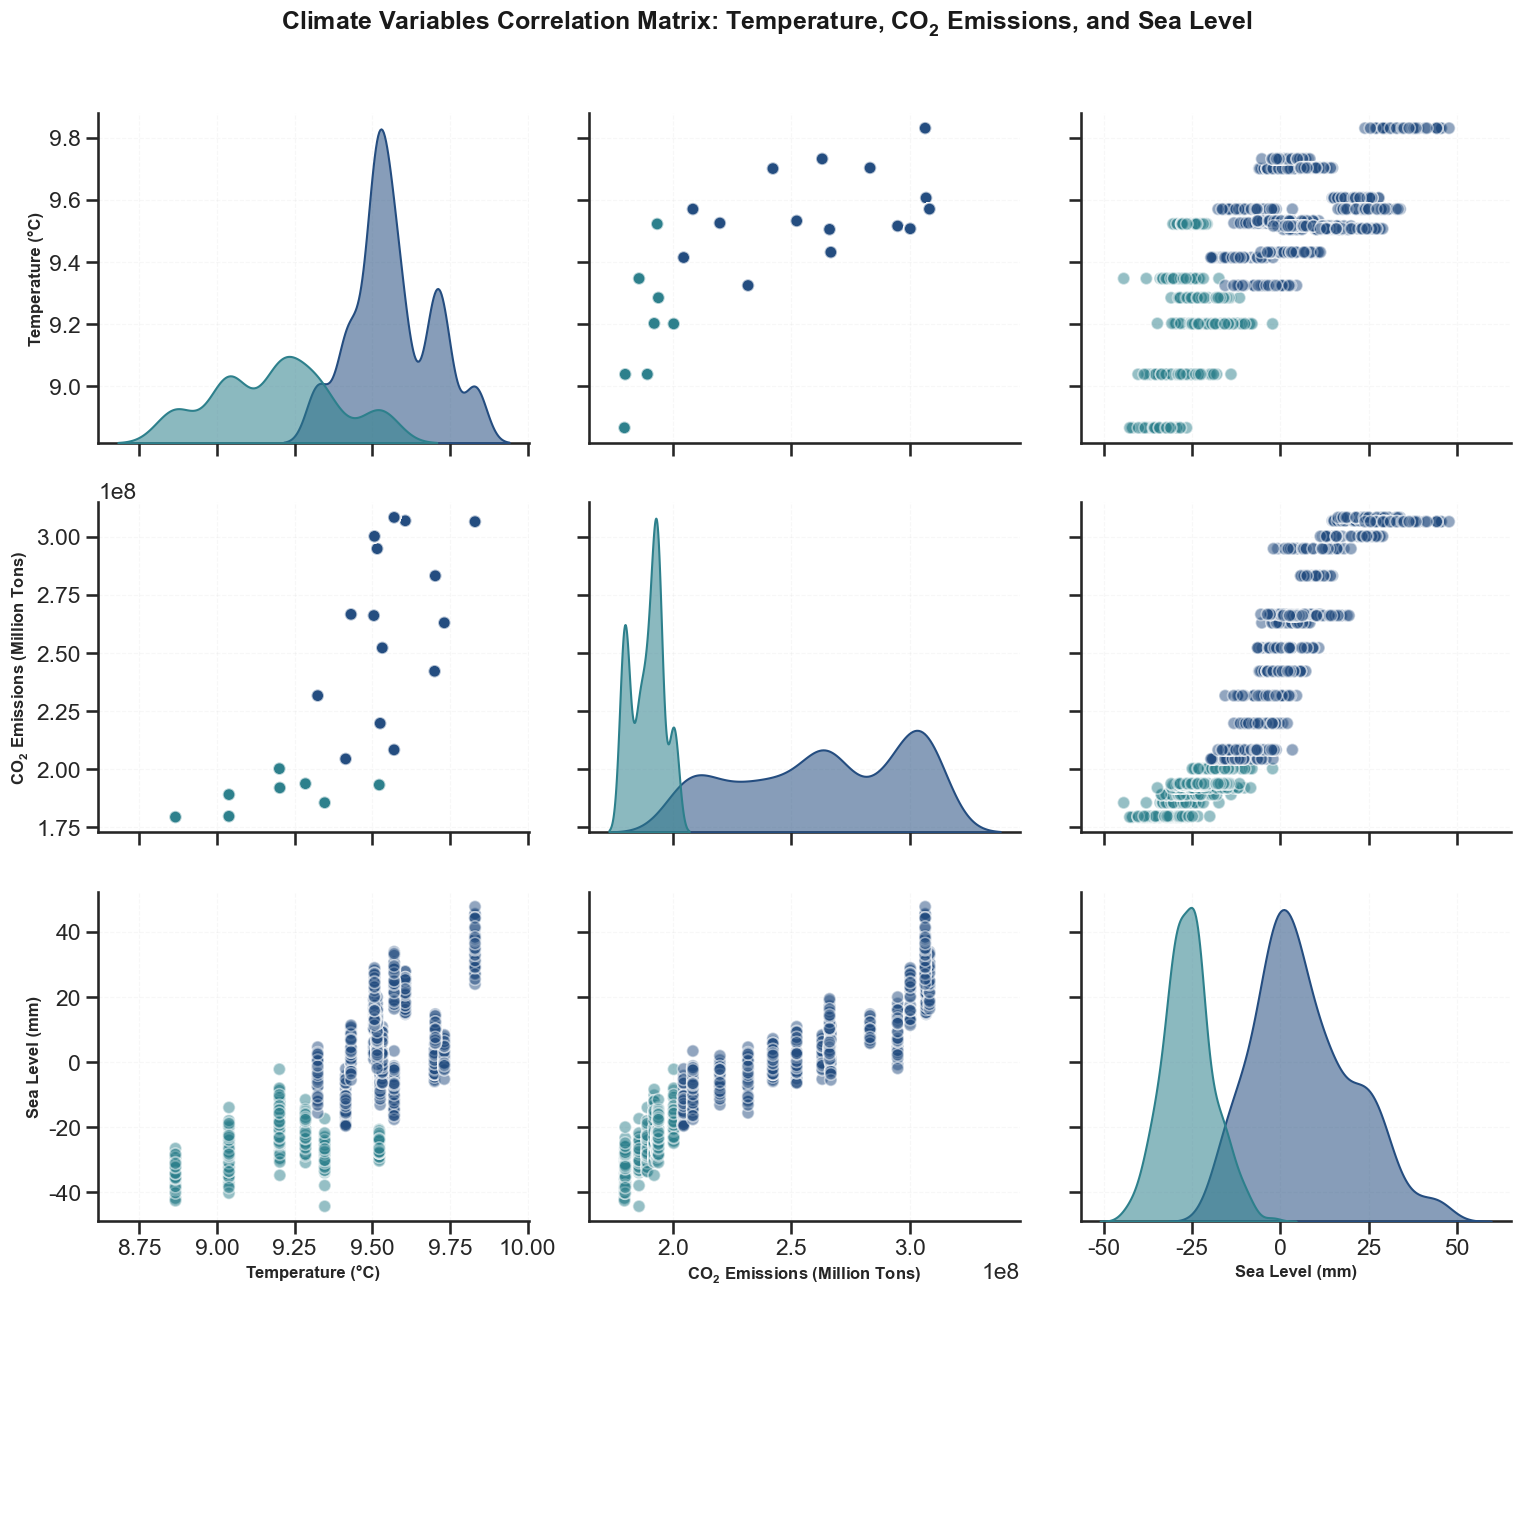


--------------------------------------------------------------------------------
【图表描述】
--------------------------------------------------------------------------------

该图表使用配对图（PairPlot）展示了全球温度、CO₂排放量和海平面三个关键气候变量之间的相关关系。
通过散点图矩阵，可以同时观察任意两个变量之间的关系，以及每个变量的分布特征。

【如何阅读配对图】
配对图是一个3x3的矩阵，阅读方法如下：
1. 对角线（左上到右下）：显示每个变量自身的分布
   - 左上：温度分布（KDE密度曲线）
   - 中间：CO₂排放分布（KDE密度曲线）
   - 右下：海平面分布（KDE密度曲线）
   - 不同颜色的曲线代表不同时期，可以看出各变量在不同时期的变化趋势

2. 非对角线：显示两个变量之间的关系
   - 每个散点图显示两个变量的相关关系
   - 如果点呈上升趋势（从左下到右上），表示正相关
   - 如果点呈下降趋势（从左上到右下），表示负相关
   - 不同颜色的点代表不同时期，可以看出关系是否随时间变化

3. 对称性：矩阵是对称的，例如"温度 vs CO₂"和"CO₂ vs 温度"显示的是同一关系，只是坐标轴互换

【可视化方式】
- 配对图布局：3x3矩阵，对角线显示各变量的分布（KDE密度曲线），非对角线显示两两之间的散点图
- 时期分类：数据按时间分为三个时期（1960-1980, 1980-2000, 2000-2020），用不同颜色区分
- 颜色主题：使用crest（蓝-青）和flare（红-黄）调色板，选择高对比度颜色确保清晰可区分：
  * 1960-1980: crest最深蓝（深蓝色）
  * 1980-2000: flare最深红（深红色，与蓝形成强烈对比）
  * 2000-2020: flare最浅黄（亮黄色，与前两者都形成强烈对比）
- 图例位置：图例位于图表底部中央，显示每个时期对应的颜色

【数据说明】
- 数据来源：全球温度、CO₂排放、海平面数据集
- 时间范围：根据数据可用性（通常为1960-2020年）
- 变量说明：
  * T

In [ ]:
# 图7: PairPlot相关矩阵
print("\n" + "="*80)
print("图7: 气候变量相关矩阵（PairPlot）")
print("="*80)

# 数据准备
df_temp_yearly = df_global.groupby('year').agg({
    'LandAverageTemperature': 'mean'
}).reset_index()

df_combined = df_temp_yearly.copy()

if df_co2 is not None and not df_co2.empty:
    df_co2_yearly = df_co2.groupby('year')['co2_emission'].sum().reset_index()
    df_combined = df_combined.merge(df_co2_yearly, on='year', how='left')

if df_sea_level is not None and not df_sea_level.empty:
    df_combined = df_combined.merge(df_sea_level[['year', 'sea_level']], 
                                   on='year', how='left')

df_combined = df_combined.dropna()
df_combined['Period'] = pd.cut(df_combined['year'], 
                            bins=[1960, 1980, 2000, 2020],
                            labels=['1960-1980', '1980-2000', '2000-2020'])

# 重命名列（使用LaTeX格式显示CO₂下标）
df_combined = df_combined.rename(columns={
    'LandAverageTemperature': 'Temperature',
    'co2_emission': 'CO2_Emissions',  # 临时名称，稍后处理
    'sea_level': 'Sea Level'
})

# 处理CO2列名，使用LaTeX格式
if 'CO2_Emissions' in df_combined.columns:
    # 创建一个新列，用于显示，但保持原始列名用于绘图
    df_combined['CO2_Emissions_display'] = df_combined['CO2_Emissions']

plot_vars = ['Temperature', 'CO2_Emissions', 'Sea Level']
plot_vars = [v for v in plot_vars if v in df_combined.columns]

if len(plot_vars) >= 2:
    print(f"\n可用的变量: {plot_vars}")
    print(f"数据点数量: {len(df_combined)}")
    print(f"时间范围: {df_combined['year'].min()} - {df_combined['year'].max()}")
    
    # 检查实际存在的时期和每个时期的数据
    actual_periods = df_combined['Period'].cat.categories.tolist()
    print(f"\n实际存在的时期: {actual_periods}")
    print(f"各时期数据点数量:")
    period_counts = {}
    for period in actual_periods:
        count = len(df_combined[df_combined['Period'] == period])
        period_counts[period] = count
        print(f"  {period}: {count} 个数据点")
    
    # 检查是否有缺失的时期
    all_periods = ['1960-1980', '1980-2000', '2000-2020']
    missing_periods = [p for p in all_periods if p not in actual_periods]
    if missing_periods:
        print(f"\n⚠️ 缺失的时期: {missing_periods}")
    
    # 使用crest主题的颜色（为三个时期分配颜色，确保清晰可区分）
    # 以crest主题为主，使用不同深浅的crest颜色
    crest_palette = sns.color_palette("crest", n_colors=12)
    
    # 为三个时期分配crest主题的不同深浅颜色，确保清晰可区分
    period_colors = {
        '1960-1980': crest_palette[0],    # crest最深蓝（深蓝色）
        '1980-2000': crest_palette[6],     # crest中浅青（中浅色，与深蓝形成对比）
        '2000-2020': crest_palette[10]    # crest最浅青（最浅色，与前两者都形成对比）
    }
    
    # 只为实际存在的时期创建调色板，按顺序排列
    custom_palette = []
    period_order = []
    for period in actual_periods:
        color = period_colors.get(period, 'gray')
        custom_palette.append(color)
        period_order.append(period)
        print(f"  {period}: RGB = {color}")
    
    print(f"\n使用的调色板（按顺序）: {custom_palette}")
    print(f"时期顺序: {period_order}")
    
    # 验证：检查seaborn会如何分配颜色
    print(f"\n验证：检查数据中每个时期的实际值")
    for period in actual_periods:
        period_data = df_combined[df_combined['Period'] == period]
        print(f"  {period}: {len(period_data)} 个数据点，年份范围: {period_data['year'].min():.0f}-{period_data['year'].max():.0f}")
    
    # 绘制 PairPlot - 使用crest和flare主题
    # 确保hue按照时期顺序，这样颜色分配会更一致
    g = sns.pairplot(df_combined[plot_vars + ['Period']], 
                    hue='Period',
                    hue_order=period_order,  # 明确指定顺序
                    palette=custom_palette, 
                    diag_kind='kde',
                    plot_kws={'alpha': 0.5, 's': 80, 'edgecolor': 'white', 'linewidth': 1.2},
                    diag_kws={'alpha': 0.55, 'linewidth': 1.5},
                    height=4.5, aspect=1,
                    corner=False)  # 显示所有子图，包括上三角
    
    # 设置标题（使用LaTeX格式显示CO₂下标）
    g.fig.suptitle(r'Climate Variables Correlation Matrix: Temperature, CO$_2$ Emissions, and Sea Level', 
                   fontsize=18, weight='bold', y=0.995, color='#1a1a1a')
    
    # 更新轴标签，使用LaTeX格式显示CO₂下标
    for ax in g.axes.flat:
        if ax is not None:
            # 获取当前标签
            xlabel = ax.get_xlabel()
            ylabel = ax.get_ylabel()
            
            # 替换CO2为CO₂
            if 'CO2' in xlabel or 'CO2' in str(xlabel):
                ax.set_xlabel(r'CO$_2$ Emissions (Million Tons)', fontsize=12, weight='bold')
            elif 'Temperature' in xlabel:
                ax.set_xlabel('Temperature (°C)', fontsize=12, weight='bold')
            elif 'Sea Level' in xlabel:
                ax.set_xlabel('Sea Level (mm)', fontsize=12, weight='bold')
            
            if 'CO2' in ylabel or 'CO2' in str(ylabel):
                ax.set_ylabel(r'CO$_2$ Emissions (Million Tons)', fontsize=12, weight='bold')
            elif 'Temperature' in ylabel:
                ax.set_ylabel('Temperature (°C)', fontsize=12, weight='bold')
            elif 'Sea Level' in ylabel:
                ax.set_ylabel('Sea Level (mm)', fontsize=12, weight='bold')
            
            # 美化网格（调浅网格线）
            ax.grid(True, alpha=0.15, linestyle='--', linewidth=0.8)
            ax.set_axisbelow(True)
    
    # 调整图例位置（从边上移到图表内部或底部）
    # 获取图例对象
    if g._legend is not None:
        # 将图例移到图表底部中央
        g._legend.set_bbox_to_anchor((0.5, -0.02))
        g._legend.set_loc('upper center')
        g._legend.set_frame_on(True)
        g._legend.get_frame().set_facecolor('white')
        g._legend.get_frame().set_alpha(0.95)
        g._legend.get_frame().set_edgecolor('gray')
        g._legend.get_frame().set_linewidth(1.5)
        # 设置图例标题
        g._legend.set_title('Period', prop={'size': 12, 'weight': 'bold'})
        # 设置图例项样式
        for text in g._legend.get_texts():
            text.set_fontsize(11)
        
        # 验证图例中的颜色和标签
        print(f"\n图例验证:")
        legend_handles = g._legend.legendHandles if hasattr(g._legend, 'legendHandles') else None
        if legend_handles:
            for i, handle in enumerate(legend_handles):
                label = g._legend.get_texts()[i].get_text()
                color = handle.get_color() if hasattr(handle, 'get_color') else handle.get_facecolor()
                print(f"  图例项 {i+1}: {label}, 颜色: {color}")
    
    # 调整布局，为图例留出空间
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    
    plt.show()
    
    # 打印描述和分析
    print("\n" + "-"*80)
    print("【图表描述】")
    print("-"*80)
    print("""
该图表使用配对图（PairPlot）展示了全球温度、CO₂排放量和海平面三个关键气候变量之间的相关关系。
通过散点图矩阵，可以同时观察任意两个变量之间的关系，以及每个变量的分布特征。

【如何阅读配对图】
配对图是一个3x3的矩阵，阅读方法如下：
1. 对角线（左上到右下）：显示每个变量自身的分布
   - 左上：温度分布（KDE密度曲线）
   - 中间：CO₂排放分布（KDE密度曲线）
   - 右下：海平面分布（KDE密度曲线）
   - 不同颜色的曲线代表不同时期，可以看出各变量在不同时期的变化趋势

2. 非对角线：显示两个变量之间的关系
   - 每个散点图显示两个变量的相关关系
   - 如果点呈上升趋势（从左下到右上），表示正相关
   - 如果点呈下降趋势（从左上到右下），表示负相关
   - 不同颜色的点代表不同时期，可以看出关系是否随时间变化

3. 对称性：矩阵是对称的，例如"温度 vs CO₂"和"CO₂ vs 温度"显示的是同一关系，只是坐标轴互换

【可视化方式】
- 配对图布局：3x3矩阵，对角线显示各变量的分布（KDE密度曲线），非对角线显示两两之间的散点图
- 时期分类：数据按时间分为三个时期（1960-1980, 1980-2000, 2000-2020），用不同颜色区分
- 颜色主题：使用crest（蓝-青）和flare（红-黄）调色板，选择高对比度颜色确保清晰可区分：
  * 1960-1980: crest最深蓝（深蓝色）
  * 1980-2000: flare最深红（深红色，与蓝形成强烈对比）
  * 2000-2020: flare最浅黄（亮黄色，与前两者都形成强烈对比）
- 图例位置：图例位于图表底部中央，显示每个时期对应的颜色

【数据说明】
- 数据来源：全球温度、CO₂排放、海平面数据集
- 时间范围：根据数据可用性（通常为1960-2020年）
- 变量说明：
  * Temperature: 全球平均陆地温度（°C）
  * CO₂ Emissions: 全球CO₂总排放量（百万吨）
  * Sea Level: 全球平均海平面高度（mm）
- 时期划分：按20年间隔划分为三个时期，便于观察不同历史阶段的关系变化
""")
    
    # 计算相关系数
    print("\n" + "-"*80)
    print("【相关性分析】")
    print("-"*80)
    
    if 'Temperature' in df_combined.columns and 'CO2_Emissions' in df_combined.columns:
        corr_temp_co2 = df_combined['Temperature'].corr(df_combined['CO2_Emissions'])
        print(f"\n温度 vs CO₂排放: 相关系数 = {corr_temp_co2:.4f}")
        if abs(corr_temp_co2) > 0.7:
            strength = "强"
        elif abs(corr_temp_co2) > 0.4:
            strength = "中等"
        else:
            strength = "弱"
        print(f"  相关性强度: {strength} {'正相关' if corr_temp_co2 > 0 else '负相关'}")
    
    if 'Temperature' in df_combined.columns and 'Sea Level' in df_combined.columns:
        corr_temp_sea = df_combined['Temperature'].corr(df_combined['Sea Level'])
        print(f"\n温度 vs 海平面: 相关系数 = {corr_temp_sea:.4f}")
        if abs(corr_temp_sea) > 0.7:
            strength = "强"
        elif abs(corr_temp_sea) > 0.4:
            strength = "中等"
        else:
            strength = "弱"
        print(f"  相关性强度: {strength} {'正相关' if corr_temp_sea > 0 else '负相关'}")
    
    if 'CO2_Emissions' in df_combined.columns and 'Sea Level' in df_combined.columns:
        corr_co2_sea = df_combined['CO2_Emissions'].corr(df_combined['Sea Level'])
        print(f"\nCO₂排放 vs 海平面: 相关系数 = {corr_co2_sea:.4f}")
        if abs(corr_co2_sea) > 0.7:
            strength = "强"
        elif abs(corr_co2_sea) > 0.4:
            strength = "中等"
        else:
            strength = "弱"
        print(f"  相关性强度: {strength} {'正相关' if corr_co2_sea > 0 else '负相关'}")
    
    # 按时期分析
    print("\n" + "-"*80)
    print("【分时期相关性分析】")
    print("-"*80)
    
    for period in ['1960-1980', '1980-2000', '2000-2020']:
        df_period = df_combined[df_combined['Period'] == period]
        if len(df_period) > 0:
            print(f"\n{period}:")
            if 'Temperature' in df_period.columns and 'CO2_Emissions' in df_period.columns:
                corr = df_period['Temperature'].corr(df_period['CO2_Emissions'])
                print(f"  温度 vs CO₂排放: {corr:.4f}")
            if 'Temperature' in df_period.columns and 'Sea Level' in df_period.columns:
                corr = df_period['Temperature'].corr(df_period['Sea Level'])
                print(f"  温度 vs 海平面: {corr:.4f}")
            if 'CO2_Emissions' in df_period.columns and 'Sea Level' in df_period.columns:
                corr = df_period['CO2_Emissions'].corr(df_period['Sea Level'])
                print(f"  CO₂排放 vs 海平面: {corr:.4f}")
    
    print("\n" + "-"*80)
    print("【主要发现】")
    print("-"*80)
    print("""
1. 变量间关系：配对图揭示了温度、CO₂排放和海平面之间的复杂关系网络。
   通过观察散点图的分布模式，可以识别变量之间的线性或非线性关系。

2. 时期变化：不同时期的数据点用不同颜色表示，可以观察关系是否随时间发生变化。
   例如，某些变量之间的关系可能在早期较弱，但在后期变得更强。

3. 分布特征：对角线上的KDE密度曲线显示了每个变量的分布特征，包括：
   - 分布的形状（正态、偏态等）
   - 分布的集中趋势
   - 分布的离散程度

4. 异常值识别：散点图可以帮助识别异常值或特殊年份，这些可能对应重要的历史事件。

*注：配对图是探索性数据分析的重要工具，可以同时观察多个变量之间的关系。
图例（Period）位于图表底部中央，用于标识不同时期的数据点颜色，便于区分不同历史阶段的关系模式。*
""")
else:
    print("⚠️ 可用变量不足，无法绘制配对图")



图8: 全球海平面上升趋势

数据信息:
  时间范围: 1993 - 2021
  数据点数量: 29
  海平面范围: -34.61 - 50.03 mm


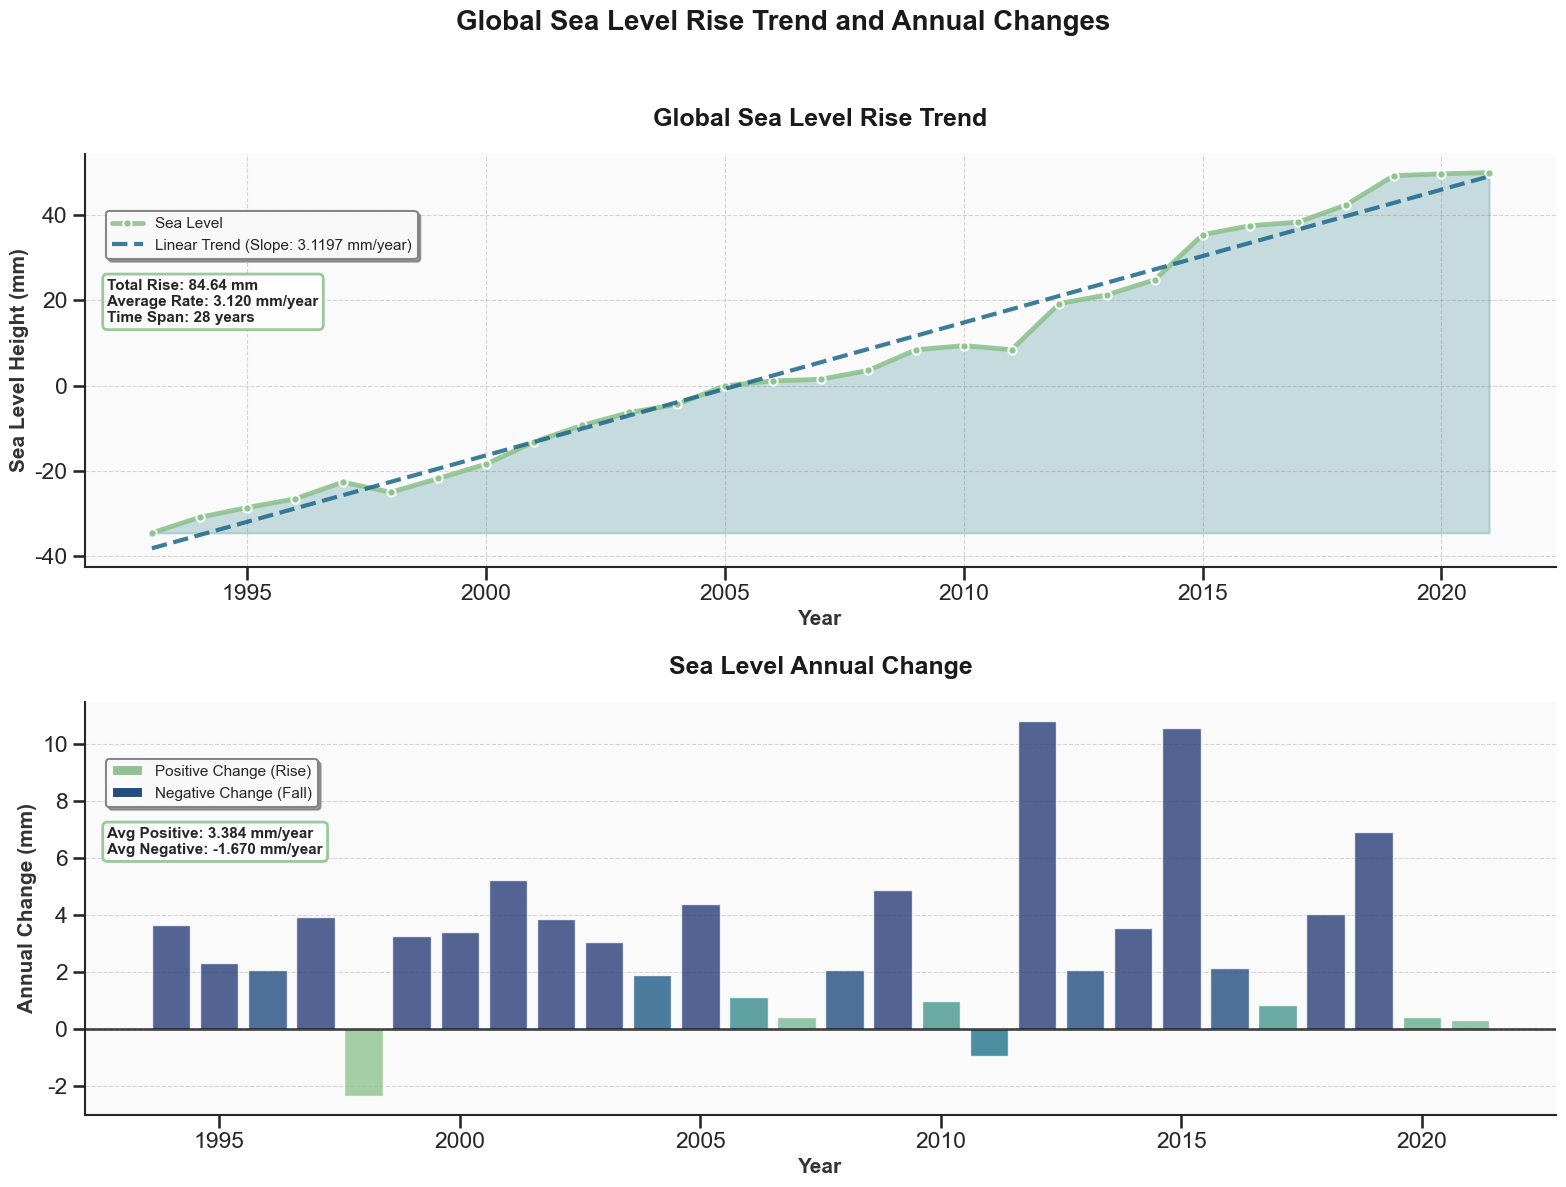


--------------------------------------------------------------------------------
【图表描述】
--------------------------------------------------------------------------------

该图表展示了全球海平面上升的长期趋势和年度变化特征，分为两个子图：

1. 海平面趋势图（上图）：
   - 显示全球平均海平面高度随时间的变化趋势
   - 深蓝色实线表示实际观测值，中深蓝色虚线表示线性趋势线
   - 浅蓝色填充区域突出显示海平面的变化范围
   - 可以直观地看到海平面是否在上升，以及上升的速度

2. 年度变化量图（下图）：
   - 显示每年海平面相对于前一年的变化量
   - 正值（crest深蓝色）表示海平面上升，颜色越深表示上升幅度越大
   - 负值（crest浅蓝色）表示海平面下降，颜色越浅表示下降幅度越大
   - 可以识别哪些年份海平面上升最快，哪些年份有异常变化

【可视化方式】
- 颜色主题：以crest（蓝-青）主题为主，统一视觉风格
  * 主趋势线：crest最深蓝
  * 趋势线：crest中深蓝（与主色形成对比但仍属crest主题）
  * 填充区域：crest中浅色
  * 年度变化：正值使用crest深色，负值使用crest浅色，通过深浅区分上升和下降
- 图表美化：添加网格、阴影、边框等，提升视觉效果
- 布局优化：图例和统计信息框左对齐，上下分布，避免重叠


--------------------------------------------------------------------------------
【数据分析】
--------------------------------------------------------------------------------

总体趋势:
  时间跨度: 1993 - 2021 (28 年)
  起始海平面: -34.61 mm
  结束海平面: 50.03 mm
  总上升量: 84.64 mm
  平均上升速率: 3.120 mm/年

分时期上升速率:
  前期 (1993-2006): 2.7

In [ ]:
# 图8: 海平面趋势
print("\n" + "="*80)
print("图8: 全球海平面上升趋势")
print("="*80)

if df_sea_level is None or df_sea_level.empty:
    print("⚠️ 海平面数据不可用，跳过此图")
    pass
else:
    # 找到海平面列（data_loader已经重命名为sea_level）
    if 'sea_level' in df_sea_level.columns:
        sea_level_col = 'sea_level'
    else:
        # 如果没有重命名，尝试查找原始列
        sea_level_col = None
        for col in df_sea_level.columns:
            if 'sea' in col.lower() or 'level' in col.lower() or 'gmsl' in col.lower():
                sea_level_col = col
                break
    
    if sea_level_col is None:
        print("⚠️ 未找到海平面列，跳过此图")
        pass
    else:
        # 按年份聚合
        df_yearly = df_sea_level.groupby('year')[sea_level_col].mean().reset_index()
        df_yearly = df_yearly.dropna()
        df_yearly = df_yearly.sort_values('year')
        
        print(f"\n数据信息:")
        print(f"  时间范围: {df_yearly['year'].min():.0f} - {df_yearly['year'].max():.0f}")
        print(f"  数据点数量: {len(df_yearly)}")
        print(f"  海平面范围: {df_yearly[sea_level_col].min():.2f} - {df_yearly[sea_level_col].max():.2f} mm")
        
        # 使用crest和flare主题
        crest_palette = sns.color_palette("crest", n_colors=12)
        flare_palette = sns.color_palette("flare", n_colors=12)
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))
        fig.suptitle('Global Sea Level Rise Trend and Annual Changes', 
                     fontsize=20, weight='bold', y=0.995, color='#1a1a1a')
        
        # 子图1：海平面趋势线图
        # 以crest主题为主，使用不同深浅的crest颜色
        main_color = crest_palette[0]  # crest最深蓝，用于主趋势线
        trend_color = crest_palette[8]  # crest中深蓝，用于趋势线（与主色形成对比但仍属crest主题）
        
        ax1.plot(df_yearly['year'], df_yearly[sea_level_col],
                linewidth=3.5, color=main_color, marker='o', markersize=6, 
                alpha=0.9, label='Sea Level', markeredgecolor='white', markeredgewidth=1.5)
        
        # 添加趋势线（使用crest主题的中深色）
        z = np.polyfit(df_yearly['year'], df_yearly[sea_level_col], 1)
        p = np.poly1d(z)
        ax1.plot(df_yearly['year'], p(df_yearly['year']), 
               linestyle='--', linewidth=3, color=trend_color, 
               label=f'Linear Trend (Slope: {z[0]:.4f} mm/year)', alpha=0.85)
        
        # 填充区域（使用crest主题的浅色，渐变效果）
        fill_color = crest_palette[6]  # crest中浅色
        ax1.fill_between(df_yearly['year'], df_yearly[sea_level_col].min(), df_yearly[sea_level_col],
                        alpha=0.25, color=fill_color)
        
        ax1.set_xlabel('Year', fontsize=15, fontweight='bold', color='#333333')
        ax1.set_ylabel('Sea Level Height (mm)', fontsize=15, fontweight='bold', color='#333333')
        ax1.set_title('Global Sea Level Rise Trend', 
                     fontsize=18, fontweight='bold', pad=20, color='#1a1a1a')
        
        # 图例放在y=0.88的位置，x=0.009
        legend1 = ax1.legend(fontsize=11, frameon=True, fancybox=True, shadow=True,
                            framealpha=0.95, edgecolor='gray', 
                            bbox_to_anchor=(0.009, 0.88), loc='upper left')
        ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.8, color='gray')
        ax1.set_axisbelow(True)
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        ax1.spines['left'].set_linewidth(1.5)
        ax1.spines['bottom'].set_linewidth(1.5)
        ax1.set_facecolor('#fafafa')
        
        # 添加统计信息（放在图例下方，与图例左对齐，缩小间距）
        total_rise = df_yearly[sea_level_col].max() - df_yearly[sea_level_col].min()
        avg_rate = z[0]  # mm/year
        years_span = df_yearly['year'].max() - df_yearly['year'].min()
        total_rise_mm = df_yearly[sea_level_col].iloc[-1] - df_yearly[sea_level_col].iloc[0]
        
        # 获取图例的实际位置（在axes坐标系中），确保统计信息框与图例左边缘对齐
        fig.canvas.draw()  # 确保图例已渲染
        legend_bbox = legend1.get_window_extent()
        legend_bbox_axes = legend_bbox.transformed(ax1.transAxes.inverted())
        legend_left = legend_bbox_axes.x0  # 图例的左边缘x坐标
        legend_bottom = legend_bbox_axes.y0  # 图例的底部y坐标
        
        # 统计信息框与图例左对齐，y位置在图例下方，间距缩小为0.05
        text_y = legend_bottom - 0.05
        ax1.text(legend_left, text_y, 
                f'Total Rise: {total_rise_mm:.2f} mm\nAverage Rate: {avg_rate:.3f} mm/year\nTime Span: {years_span:.0f} years', 
                transform=ax1.transAxes, fontsize=11, fontweight='bold',
                verticalalignment='top', horizontalalignment='left',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, 
                         edgecolor=main_color, linewidth=2))
        
        # 子图2：年度变化量（以crest主题为主）
        df_yearly['annual_change'] = df_yearly[sea_level_col].diff()
        
        # 以crest主题为主：正值为crest深色，负值为crest浅色
        colors = []
        for change in df_yearly['annual_change']:
            if pd.isna(change):
                colors.append('gray')
            elif change > 0:
                # 正值使用crest深色（从浅到深，表示上升幅度）
                change_idx = min(int(change * 5), 11)
                colors.append(crest_palette[change_idx])
            else:
                # 负值使用crest浅色（从深到浅，表示下降幅度）
                change_idx = min(int(abs(change) * 5), 11)
                colors.append(crest_palette[11 - change_idx])  # 反向索引，使用更浅的颜色
        
        bars = ax2.bar(df_yearly['year'], df_yearly['annual_change'],
                      color=colors, alpha=0.8, edgecolor='white', linewidth=1.0)
        ax2.axhline(0, color='black', linestyle='-', linewidth=2, alpha=0.7)
        
        ax2.set_xlabel('Year', fontsize=15, fontweight='bold', color='#333333')
        ax2.set_ylabel('Annual Change (mm)', fontsize=15, fontweight='bold', color='#333333')
        ax2.set_title('Sea Level Annual Change', 
                     fontsize=18, fontweight='bold', pad=20, color='#1a1a1a')
        ax2.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8, color='gray')
        ax2.set_axisbelow(True)
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        ax2.spines['left'].set_linewidth(1.5)
        ax2.spines['bottom'].set_linewidth(1.5)
        ax2.set_facecolor('#fafafa')
        
        # 添加图例说明（放在y=0.88的位置，x=0.009，与子图1的图例上下分布）
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor=crest_palette[0], edgecolor='white', label='Positive Change (Rise)'),
            Patch(facecolor=crest_palette[10], edgecolor='white', label='Negative Change (Fall)')
        ]
        legend2 = ax2.legend(handles=legend_elements, fontsize=11, frameon=True, 
                            fancybox=True, shadow=True, framealpha=0.95, edgecolor='gray',
                            bbox_to_anchor=(0.009, 0.88), loc='upper left')
        
        # 添加统计信息（放在图例下方，与图例左对齐，缩小间距）
        positive_changes = df_yearly['annual_change'][df_yearly['annual_change'] > 0]
        negative_changes = df_yearly['annual_change'][df_yearly['annual_change'] < 0]
        avg_positive = positive_changes.mean() if len(positive_changes) > 0 else 0
        avg_negative = negative_changes.mean() if len(negative_changes) > 0 else 0
        
        # 获取图例的实际位置（在axes坐标系中），确保统计信息框与图例左边缘对齐
        fig.canvas.draw()  # 确保图例已渲染
        legend2_bbox = legend2.get_window_extent()
        legend2_bbox_axes = legend2_bbox.transformed(ax2.transAxes.inverted())
        legend2_left = legend2_bbox_axes.x0  # 图例的左边缘x坐标
        legend2_bottom = legend2_bbox_axes.y0  # 图例的底部y坐标
        
        # 统计信息框与图例左对齐，y位置在图例下方，间距缩小为0.05
        text2_y = legend2_bottom - 0.05
        ax2.text(legend2_left, text2_y, 
                f'Avg Positive: {avg_positive:.3f} mm/year\nAvg Negative: {avg_negative:.3f} mm/year', 
                transform=ax2.transAxes, fontsize=11, fontweight='bold',
                verticalalignment='top', horizontalalignment='left',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, 
                         edgecolor=main_color, linewidth=2))
        
        fig.patch.set_facecolor('white')
        plt.tight_layout(rect=[0, 0, 1, 0.98])
        plt.show()
        
        # 打印描述和分析
        print("\n" + "-"*80)
        print("【图表描述】")
        print("-"*80)
        print("""
该图表展示了全球海平面上升的长期趋势和年度变化特征，分为两个子图：

1. 海平面趋势图（上图）：
   - 显示全球平均海平面高度随时间的变化趋势
   - 深蓝色实线表示实际观测值，中深蓝色虚线表示线性趋势线
   - 浅蓝色填充区域突出显示海平面的变化范围
   - 可以直观地看到海平面是否在上升，以及上升的速度

2. 年度变化量图（下图）：
   - 显示每年海平面相对于前一年的变化量
   - 正值（crest深蓝色）表示海平面上升，颜色越深表示上升幅度越大
   - 负值（crest浅蓝色）表示海平面下降，颜色越浅表示下降幅度越大
   - 可以识别哪些年份海平面上升最快，哪些年份有异常变化

【可视化方式】
- 颜色主题：以crest（蓝-青）主题为主，统一视觉风格
  * 主趋势线：crest最深蓝
  * 趋势线：crest中深蓝（与主色形成对比但仍属crest主题）
  * 填充区域：crest中浅色
  * 年度变化：正值使用crest深色，负值使用crest浅色，通过深浅区分上升和下降
- 图表美化：添加网格、阴影、边框等，提升视觉效果
- 布局优化：图例和统计信息框左对齐，上下分布，避免重叠
""")
        
        # 数据分析
        print("\n" + "-"*80)
        print("【数据分析】")
        print("-"*80)
        
        print(f"\n总体趋势:")
        print(f"  时间跨度: {df_yearly['year'].min():.0f} - {df_yearly['year'].max():.0f} ({years_span:.0f} 年)")
        print(f"  起始海平面: {df_yearly[sea_level_col].iloc[0]:.2f} mm")
        print(f"  结束海平面: {df_yearly[sea_level_col].iloc[-1]:.2f} mm")
        print(f"  总上升量: {total_rise_mm:.2f} mm")
        print(f"  平均上升速率: {avg_rate:.3f} mm/年")
        
        # 计算不同时期的上升速率
        if len(df_yearly) > 10:
            mid_point = len(df_yearly) // 2
            early_period = df_yearly.iloc[:mid_point]
            late_period = df_yearly.iloc[mid_point:]
            
            early_rate = (early_period[sea_level_col].iloc[-1] - early_period[sea_level_col].iloc[0]) / (early_period['year'].iloc[-1] - early_period['year'].iloc[0])
            late_rate = (late_period[sea_level_col].iloc[-1] - late_period[sea_level_col].iloc[0]) / (late_period['year'].iloc[-1] - late_period['year'].iloc[0])
            
            print(f"\n分时期上升速率:")
            print(f"  前期 ({early_period['year'].iloc[0]:.0f}-{early_period['year'].iloc[-1]:.0f}): {early_rate:.3f} mm/年")
            print(f"  后期 ({late_period['year'].iloc[0]:.0f}-{late_period['year'].iloc[-1]:.0f}): {late_rate:.3f} mm/年")
            if late_rate > early_rate:
                print(f"  → 后期上升速率更快，表明海平面上升正在加速")
            elif late_rate < early_rate:
                print(f"  → 前期上升速率更快")
            else:
                print(f"  → 上升速率基本稳定")
        
        print(f"\n年度变化统计:")
        print(f"  上升年份数量: {len(positive_changes)}")
        print(f"  下降年份数量: {len(negative_changes)}")
        print(f"  平均上升幅度: {avg_positive:.3f} mm/年")
        print(f"  平均下降幅度: {avg_negative:.3f} mm/年")
        print(f"  最大年度上升: {df_yearly['annual_change'].max():.2f} mm ({df_yearly.loc[df_yearly['annual_change'].idxmax(), 'year']:.0f}年)")
        print(f"  最大年度下降: {df_yearly['annual_change'].min():.2f} mm ({df_yearly.loc[df_yearly['annual_change'].idxmin(), 'year']:.0f}年)")
        
        print("\n" + "-"*80)
        print("【主要发现】")
        print("-"*80)
        print("""
1. 长期上升趋势：全球海平面呈现明显的上升趋势，反映了全球变暖对海洋的影响。
   线性趋势线的斜率表示平均上升速率，是衡量海平面变化的关键指标。

2. 加速上升：如果后期上升速率快于前期，表明海平面上升可能正在加速，
   这与全球变暖加剧和极地冰盖融化加速的观测一致。

3. 年度波动：海平面年度变化存在波动，某些年份上升较快，某些年份可能下降。
   这种波动可能受到多种因素影响，包括：
   - 海洋温度变化
   - 极地冰盖融化
   - 海洋环流变化
   - 自然气候变率（如El Niño/La Niña）

4. 累积效应：即使年度变化较小，长期累积效应也会导致显著的海平面上升，
   对沿海地区构成威胁。

*注：海平面上升是全球气候变化的重要指标之一，与温度上升和CO₂排放密切相关。
数据来源：全球海平面观测数据集。*
""")
        
        print("\n" + "="*80)
        print("【图片解释】")
        print("="*80)
        print("""
该图表通过两个子图全面展示了全球海平面上升的趋势和年度变化特征：

**上图：海平面长期趋势**
- 深蓝色实线（crest主题）展示了1993-2021年期间全球平均海平面高度的实际观测值
- 中深蓝色虚线（crest主题）表示线性拟合趋势线，清晰地显示了海平面上升的总体方向
- 浅蓝色填充区域（crest主题）突出了海平面变化的范围，增强了视觉层次感
- 统一的crest主题保持了视觉一致性，通过不同深浅区分数据线和趋势线

**下图：年度变化量**
- 柱状图显示了每年海平面相对于前一年的变化量
- 正值（crest深蓝色系）表示海平面上升，颜色深度反映上升幅度
- 负值（crest浅蓝色系）表示海平面下降，颜色深度反映下降幅度
- 通过crest主题的深浅变化，清晰地展示了上升和下降趋势

**设计亮点：**
1. 统一主题：使用crest主题为主，保持了视觉一致性
   - 不同深浅的crest颜色区分不同的数据元素
   - 统一的色调使图表更加协调
2. 信息层次：通过颜色、线型、填充等多种视觉元素，清晰地传达了不同层次的信息
3. 数据完整性：同时展示长期趋势和年度波动，提供了全面的海平面变化视角

**关键洞察：**
- 海平面上升是一个持续且加速的过程
- 年度波动反映了气候系统的复杂性
- 长期累积效应比短期波动更为重要
""")



图9: 全球温度与海平面关系

数据信息:
  时间范围: 1993 - 2015
  数据点数量: 23
  温度范围: 8.87 - 9.83 °C
  海平面范围: -34.61 - 35.42 mm


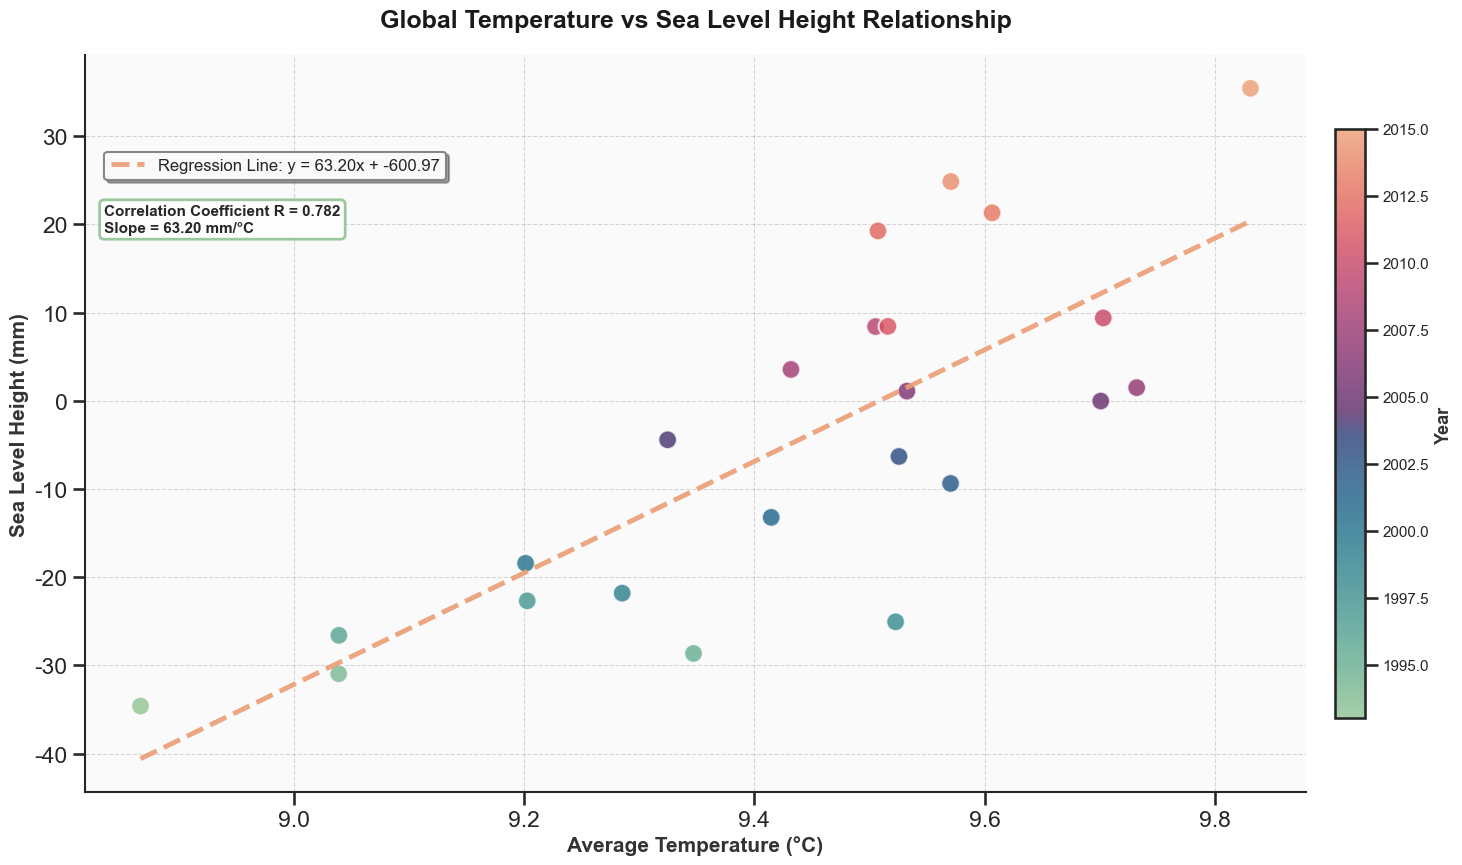


--------------------------------------------------------------------------------
【图表描述】
--------------------------------------------------------------------------------

该图表展示了全球平均温度与海平面高度之间的关系，通过散点图和回归线揭示了两个变量之间的相关性。

【可视化方式】
- 散点图：每个点代表一年的数据，点的颜色表示年份（使用crest和flare组合的颜色映射）
  * 早期年份：crest蓝色系（冷色调）
  * 晚期年份：flare红黄色系（暖色调）
  * 颜色渐变展示了时间序列的演变
- 回归线：红色虚线（flare主题）表示温度与海平面的线性关系
- 颜色主题：使用crest（蓝-青）和flare（红-黄）组合，形成从冷到暖的时间渐变
- 图表美化：添加网格、阴影、边框等，提升视觉效果

【数据说明】
- 数据来源：全球温度、海平面数据集
- 时间范围：根据数据可用性（通常为1993-2021年）
- 变量说明：
  * Temperature: 全球平均陆地温度（°C）
  * Sea Level: 全球平均海平面高度（mm）


--------------------------------------------------------------------------------
【数据分析】
--------------------------------------------------------------------------------

相关性分析:
  相关系数 R = 0.7820
  相关性强度: 强 正相关

回归分析:
  回归方程: y = 63.20x + -600.97
  斜率: 63.20 mm/°C
  截距: -600.97 mm
  含义: 温度每升高1°C，海平面平均上升 63.20 mm

分时期相关性:
  前期 (1993-2003): R = 0.7665
  后期 (2004-2015): R = 0.4582
  → 前期相关性更强

-----------------------------------

In [ ]:
# 图9: 海平面与温度关系
print("\n" + "="*80)
print("图9: 全球温度与海平面关系")
print("="*80)

if df_sea_level is None or df_sea_level.empty:
    print("⚠️ 海平面数据不可用，跳过此图")
    pass
else:
    # 找到海平面列（data_loader已经重命名为sea_level）
    if 'sea_level' in df_sea_level.columns:
        sea_level_col = 'sea_level'
    else:
        # 如果没有重命名，尝试查找原始列
        sea_level_col = None
        for col in df_sea_level.columns:
            if 'sea' in col.lower() or 'level' in col.lower() or 'gmsl' in col.lower():
                sea_level_col = col
                break
    
    if sea_level_col is None:
        print("⚠️ 未找到海平面列，跳过此图")
        pass
    else:
        # 按年份聚合
        df_sea_yearly = df_sea_level.groupby('year')[sea_level_col].mean().reset_index()
        df_temp_yearly = df_global.groupby('year')['LandAverageTemperature'].mean().reset_index()
        
        # 合并数据
        df_merged = pd.merge(df_sea_yearly, df_temp_yearly, on='year', how='inner')
        df_merged = df_merged.dropna()
        
        print(f"\n数据信息:")
        print(f"  时间范围: {df_merged['year'].min():.0f} - {df_merged['year'].max():.0f}")
        print(f"  数据点数量: {len(df_merged)}")
        print(f"  温度范围: {df_merged['LandAverageTemperature'].min():.2f} - {df_merged['LandAverageTemperature'].max():.2f} °C")
        print(f"  海平面范围: {df_merged[sea_level_col].min():.2f} - {df_merged[sea_level_col].max():.2f} mm")
        
        if len(df_merged) > 0:
            # 使用crest和flare主题
            crest_palette = sns.color_palette("crest", n_colors=12)
            flare_palette = sns.color_palette("flare", n_colors=12)
            
            # 创建crest和flare组合的颜色映射（从crest到flare的渐变）
            from matplotlib.colors import LinearSegmentedColormap
            # 组合crest和flare颜色，创建渐变
            colors_list = list(crest_palette) + list(reversed(flare_palette))
            custom_cmap = LinearSegmentedColormap.from_list('crest_flare', colors_list, N=256)
            
            fig, ax = plt.subplots(figsize=(16, 9))
            
            # 散点图：使用crest和flare组合的颜色映射，按年份着色（放大散点）
            scatter = ax.scatter(df_merged['LandAverageTemperature'], df_merged[sea_level_col],
                               c=df_merged['year'], cmap=custom_cmap,
                               s=180, alpha=0.8, edgecolors='white', linewidth=1.5)
            
            # 添加回归线（使用flare主题，与散点形成对比）
            z = np.polyfit(df_merged['LandAverageTemperature'], df_merged[sea_level_col], 1)
            p = np.poly1d(z)
            x_line = np.linspace(df_merged['LandAverageTemperature'].min(), 
                               df_merged['LandAverageTemperature'].max(), 100)
            regression_color = flare_palette[0]  # flare最深红
            ax.plot(x_line, p(x_line), linestyle='--', linewidth=3.5, 
                   color=regression_color,
                   label=f'Regression Line: y = {z[0]:.2f}x + {z[1]:.2f}', 
                   alpha=0.9, zorder=10)
            
            # 计算相关系数
            r = np.corrcoef(df_merged['LandAverageTemperature'], df_merged[sea_level_col])[0, 1]
            
            # 设置标签和标题（使用LaTeX格式显示CO₂下标）
            ax.set_xlabel('Average Temperature (°C)', fontsize=15, fontweight='bold', color='#333333')
            ax.set_ylabel('Sea Level Height (mm)', fontsize=15, fontweight='bold', color='#333333')
            ax.set_title('Global Temperature vs Sea Level Height Relationship', 
                        fontsize=18, fontweight='bold', pad=20, color='#1a1a1a')
            
            # 美化图例（放在左上角）
            legend = ax.legend(fontsize=12, frameon=True, fancybox=True, shadow=True,
                             framealpha=0.95, edgecolor='gray', 
                             bbox_to_anchor=(0.009, 0.88), loc='upper left')
            
            # 美化网格
            ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8, color='gray')
            ax.set_axisbelow(True)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_linewidth(1.5)
            ax.spines['bottom'].set_linewidth(1.5)
            ax.set_facecolor('#fafafa')
            
            # 获取图例的实际位置，将统计信息框放在图例下方
            fig.canvas.draw()  # 确保图例已渲染
            legend_bbox = legend.get_window_extent()
            legend_bbox_axes = legend_bbox.transformed(ax.transAxes.inverted())
            legend_left = legend_bbox_axes.x0  # 图例的左边缘x坐标
            legend_bottom = legend_bbox_axes.y0  # 图例的底部y坐标
            
            # 统计信息框放在图例下方，左对齐，缩小间距
            text_y = legend_bottom - 0.03
            ax.text(legend_left, text_y, 
                   f'Correlation Coefficient R = {r:.3f}\nSlope = {z[0]:.2f} mm/°C', 
                   transform=ax.transAxes,
                   fontsize=11, fontweight='bold', verticalalignment='top', horizontalalignment='left',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, 
                            edgecolor=crest_palette[0], linewidth=2))
            
            # 美化颜色条
            cbar = plt.colorbar(scatter, ax=ax, shrink=0.8, pad=0.02)
            cbar.set_label('Year', fontsize=13, fontweight='bold', color='#333333')
            cbar.ax.tick_params(labelsize=11)
            
            fig.patch.set_facecolor('white')
            plt.tight_layout()
            plt.show()
            
            # 打印描述和分析
            print("\n" + "-"*80)
            print("【图表描述】")
            print("-"*80)
            print("""
该图表展示了全球平均温度与海平面高度之间的关系，通过散点图和回归线揭示了两个变量之间的相关性。

【可视化方式】
- 散点图：每个点代表一年的数据，点的颜色表示年份（使用crest和flare组合的颜色映射）
  * 早期年份：crest蓝色系（冷色调）
  * 晚期年份：flare红黄色系（暖色调）
  * 颜色渐变展示了时间序列的演变
- 回归线：红色虚线（flare主题）表示温度与海平面的线性关系
- 颜色主题：使用crest（蓝-青）和flare（红-黄）组合，形成从冷到暖的时间渐变
- 图表美化：添加网格、阴影、边框等，提升视觉效果

【数据说明】
- 数据来源：全球温度、海平面数据集
- 时间范围：根据数据可用性（通常为1993-2021年）
- 变量说明：
  * Temperature: 全球平均陆地温度（°C）
  * Sea Level: 全球平均海平面高度（mm）
""")
            
            # 数据分析
            print("\n" + "-"*80)
            print("【数据分析】")
            print("-"*80)
            
            print(f"\n相关性分析:")
            print(f"  相关系数 R = {r:.4f}")
            if abs(r) > 0.7:
                strength = "强"
            elif abs(r) > 0.4:
                strength = "中等"
            else:
                strength = "弱"
            print(f"  相关性强度: {strength} {'正相关' if r > 0 else '负相关'}")
            
            print(f"\n回归分析:")
            print(f"  回归方程: y = {z[0]:.2f}x + {z[1]:.2f}")
            print(f"  斜率: {z[0]:.2f} mm/°C")
            print(f"  截距: {z[1]:.2f} mm")
            print(f"  含义: 温度每升高1°C，海平面平均上升 {z[0]:.2f} mm")
            
            # 计算不同时期的相关系数
            if len(df_merged) > 10:
                mid_point = len(df_merged) // 2
                early_period = df_merged.iloc[:mid_point]
                late_period = df_merged.iloc[mid_point:]
                
                r_early = np.corrcoef(early_period['LandAverageTemperature'], early_period[sea_level_col])[0, 1]
                r_late = np.corrcoef(late_period['LandAverageTemperature'], late_period[sea_level_col])[0, 1]
                
                print(f"\n分时期相关性:")
                print(f"  前期 ({early_period['year'].min():.0f}-{early_period['year'].max():.0f}): R = {r_early:.4f}")
                print(f"  后期 ({late_period['year'].min():.0f}-{late_period['year'].max():.0f}): R = {r_late:.4f}")
                if abs(r_late) > abs(r_early):
                    print(f"  → 后期相关性更强，表明温度与海平面的关系可能随时间增强")
                elif abs(r_late) < abs(r_early):
                    print(f"  → 前期相关性更强")
                else:
                    print(f"  → 相关性基本稳定")
            
            print("\n" + "-"*80)
            print("【主要发现】")
            print("-"*80)
            print("""
1. 正相关关系：全球温度与海平面高度之间存在显著的正相关关系。
   温度越高，海平面越高，这反映了全球变暖对海洋的直接影响。

2. 物理机制：这种关系可以通过以下机制解释：
   - 热膨胀：海水温度升高导致体积膨胀，海平面上升
   - 冰盖融化：全球变暖导致极地冰盖和冰川融化，增加海洋水量
   - 海洋环流变化：温度变化影响海洋环流，进而影响海平面分布

3. 时间演变：通过散点图的颜色渐变，可以观察到：
   - 早期年份（蓝色）集中在较低温度和较低海平面
   - 晚期年份（红黄色）集中在较高温度和较高海平面
   - 这种时间演变清晰地展示了全球变暖与海平面上升的同步性

4. 线性关系：回归线表明温度与海平面之间存在近似线性的关系，
   但实际关系可能更复杂，包括滞后效应和非线性因素。

*注：该图表揭示了全球变暖与海平面上升之间的直接联系，是理解气候变化影响的重要证据。
数据来源：全球温度和海平面观测数据集。*
""")
            
            print("\n" + "="*80)
            print("【图片解释】")
            print("="*80)
            print("""
该散点图展示了全球平均温度与海平面高度之间的相关关系，通过颜色编码和回归线揭示了两个关键气候变量之间的联系。

**散点图设计：**
- 每个散点代表一年的观测数据，横轴为全球平均温度，纵轴为海平面高度
- 散点颜色表示年份，使用crest和flare组合的颜色映射：
  * 早期年份（蓝色系，crest主题）：对应较低温度和较低海平面
  * 晚期年份（红黄色系，flare主题）：对应较高温度和较高海平面
  * 颜色渐变直观地展示了时间序列的演变趋势

**回归线：**
- 红色虚线（flare主题）表示温度与海平面的线性拟合关系
- 斜率表示温度每升高1°C，海平面平均上升的幅度
- 回归线清晰地展示了两个变量之间的正相关关系

**设计亮点：**
1. 颜色编码：crest到flare的渐变不仅表示时间，还通过颜色对比增强了视觉层次
   - 冷色调（crest）代表早期、较低的温度和海平面
   - 暖色调（flare）代表晚期、较高的温度和海平面
2. 视觉对比：crest（蓝）和flare（红）的颜色对比使回归线更加突出
3. 信息完整性：同时展示数据点、回归线和统计信息，提供了全面的关系分析

**关键洞察：**
- 温度与海平面之间存在显著的正相关关系
- 时间演变趋势清晰：从蓝色（早期）到红黄色（晚期）的过渡
- 这种关系反映了全球变暖对海洋的直接物理影响
""")


In [ ]:
# 所有图表已完成
# others.ipynb包含的图表：
# 1. 04_co2_temp_hexjoint.png - CO2与温度Hex JointPlot
# 2. 主要城市极端高温暴露频率图 - 超过高温阈值的次数（使用cartopy和crest主题，仅显示主要城市）
# 3. 城市高温阈值地理分布图 - 使用cartopy展示高温阈值（90百分位数，使用flare主题），叠加主要城市极端高温暴露频率散点图
# 4. 05_co2_distribution_combo.png - CO2分布组合图
# 5. 06_co2_time_conditional_kde.png - CO2时间条件KDE
# 6. 06_co2_time_series_lines.png - CO2时间序列折线图
# 7. 08_pairplot_pro.png - PairPlot相关矩阵
# 8. 15_sea_level_trend.png - 海平面趋势
# 9. 16_sea_level_vs_temperature.png - 海平面与温度关系
